In [ ]:
#Check Null Values In The Dataset¶¶
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv(r"C:\Users\KIIT\Downloads\water_potability (2).csv")
df.head(10)

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0
5,5.584087,188.313324,28748.687739,7.544869,326.678363,280.467916,8.399735,54.917862,2.559708,0
6,10.223862,248.071735,28749.716544,7.513408,393.663396,283.651634,13.789695,84.603556,2.672989,0
7,8.635849,203.361523,13672.091764,4.563009,303.309771,474.607645,12.363817,62.798309,4.401425,0
8,NaN,118.988579,14285.583854,7.804174,268.646941,389.375566,12.706049,53.928846,3.595017,0
9,11.180284,227.231469,25484.508491,9.077200,404.041635,563.885481,17.927806,71.976601,4.370562,0


In [4]:
df.shape

(3276, 10)

In [5]:
df.nunique()

ph                 2785
Hardness           3276
Solids             3276
Chloramines        3276
Sulfate            2495
Conductivity       3276
Organic_carbon     3276
Trihalomethanes    3114
Turbidity          3276
Potability            2
dtype: int64

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


In [7]:
df.isna().sum()

ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64

In [8]:
df.describe()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
count,2785.000000,3276.000000,3276.000000,3276.000000,2495.000000,3276.000000,3276.000000,3114.000000,3276.000000,3276.000000
mean,7.080795,196.369496,22014.092526,7.122277,333.775777,426.205111,14.284970,66.396293,3.966786,0.390110
std,1.594320,32.879761,8768.570828,1.583085,41.416840,80.824064,3.308162,16.175008,0.780382,0.487849
min,0.000000,47.432000,320.942611,0.352000,129.000000,181.483754,2.200000,0.738000,1.450000,0.000000
25%,6.093092,176.850538,15666.690297,6.127421,307.699498,365.734414,12.065801,55.844536,3.439711,0.000000
50%,7.036752,196.967627,20927.833607,7.130299,333.073546,421.884968,14.218338,66.622485,3.955028,0.000000
75%,8.062066,216.667456,27332.762127,8.114887,359.950170,481.792304,16.557652,77.337473,4.500320,1.000000
max,14.000000,323.124000,61227.196008,13.127000,481.030642,753.342620,28.300000,124.000000,6.739000,1.000000


In [9]:
df.Potability.value_counts()

Potability
0    1998
1    1278
Name: count, dtype: int64

In [10]:
(1998/3276)*100

60.98901098901099

In [11]:

df[df['Potability']==0].isna().sum()

ph                 314
Hardness             0
Solids               0
Chloramines          0
Sulfate            488
Conductivity         0
Organic_carbon       0
Trihalomethanes    107
Turbidity            0
Potability           0
dtype: int64

In [12]:
df[df['Potability']==1].isna().sum()

ph                 177
Hardness             0
Solids               0
Chloramines          0
Sulfate            293
Conductivity         0
Organic_carbon       0
Trihalomethanes     55
Turbidity            0
Potability           0
dtype: int64

In [13]:
#Both categories contain null values in 3 columns. We impute the null values with the mean of specific category and column instead of population mean so that the possibility of clashing with the target variable is avoided.

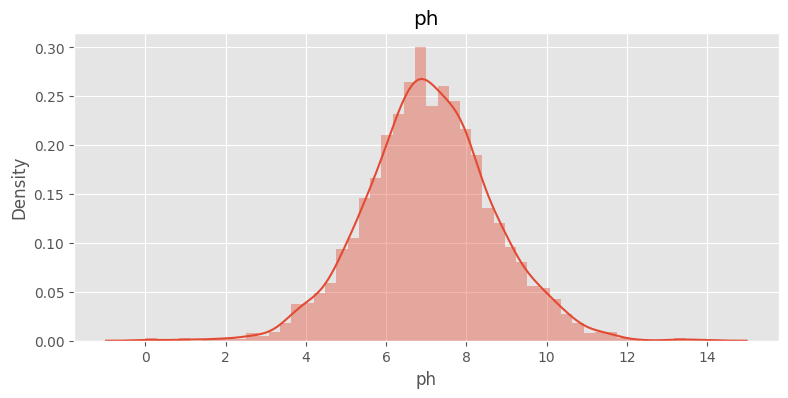

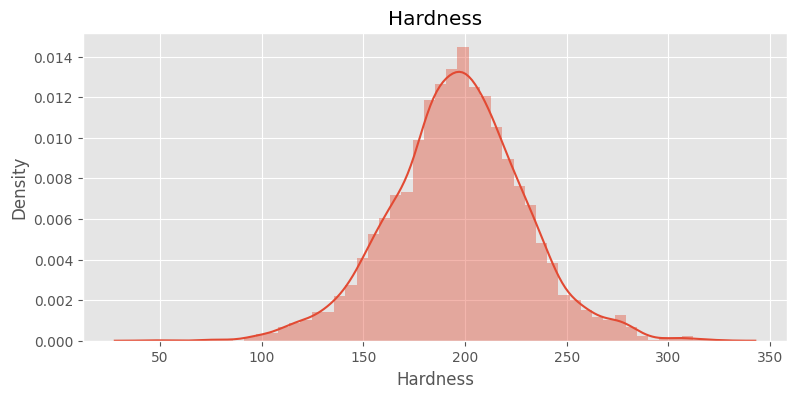

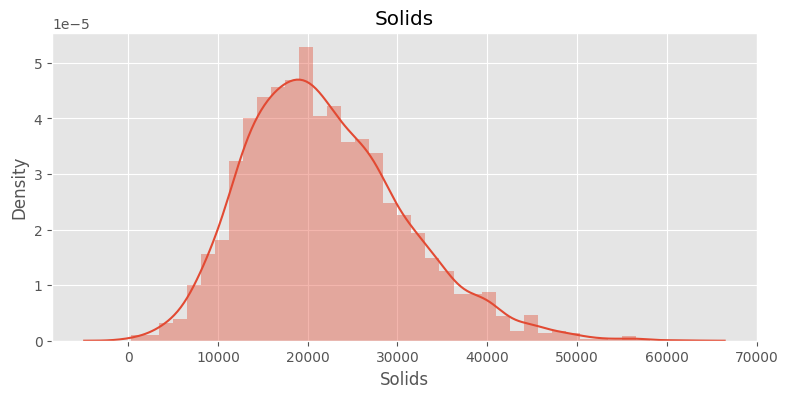

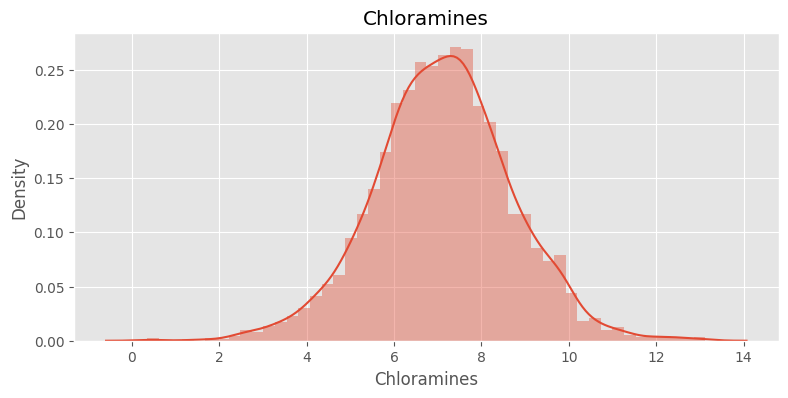

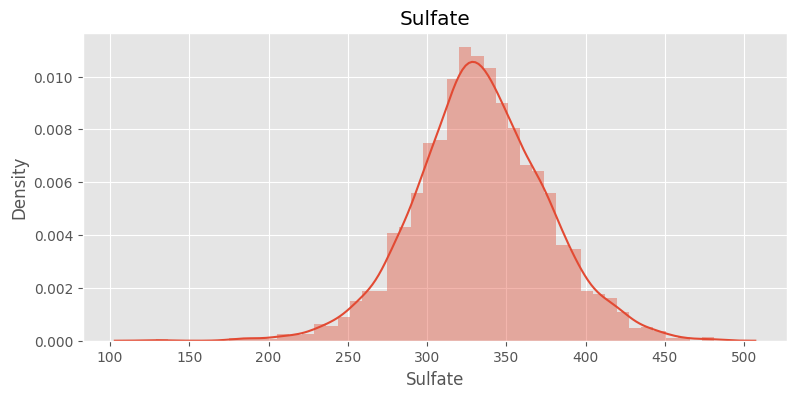

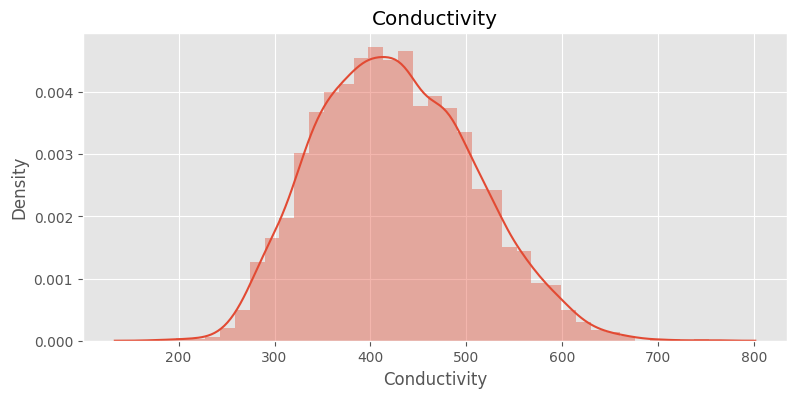

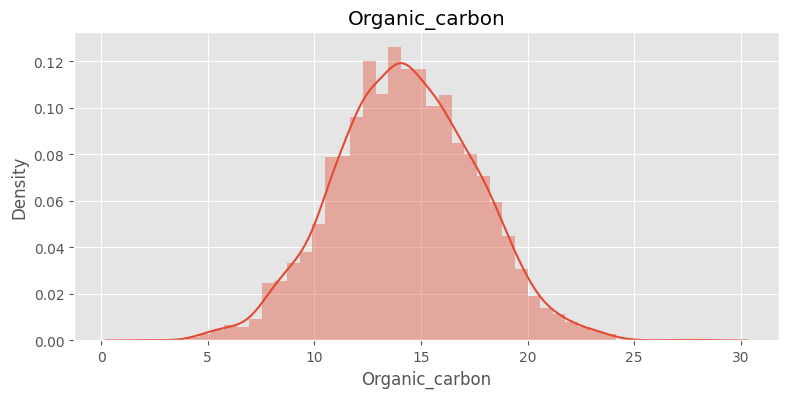

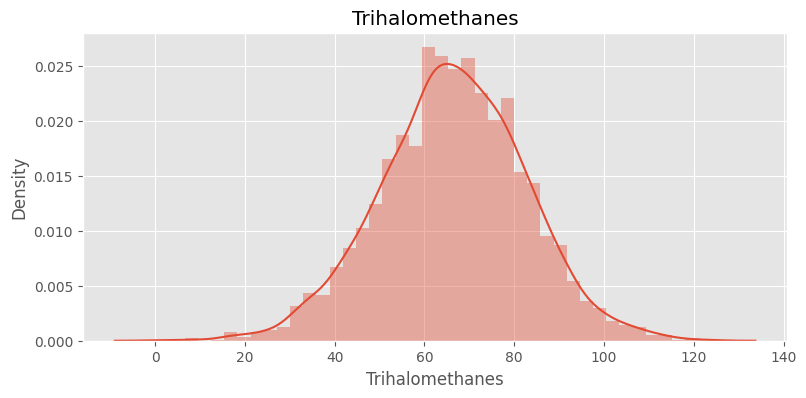

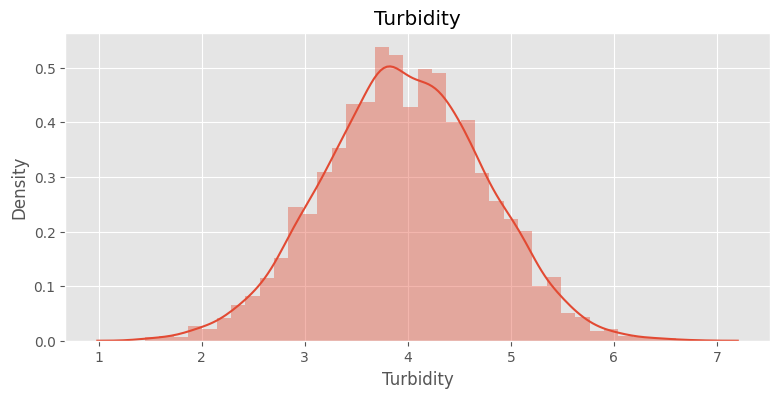

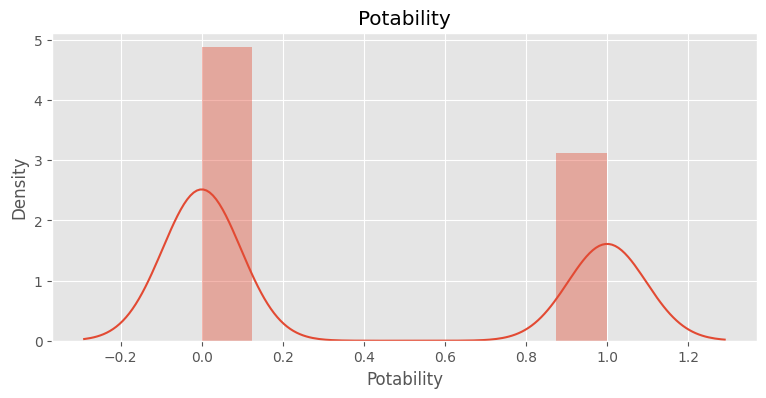

In [14]:
# plotting histogram for each numerical variable
plt.style.use("ggplot")
for column in df.columns:
    plt.figure(figsize=(20,4))
    plt.subplot(121)
    sns.distplot(df[column], kde=True)
    plt.title(column)

In [15]:
df.skew()

ph                 0.025630
Hardness          -0.039342
Solids             0.621634
Chloramines       -0.012098
Sulfate           -0.035947
Conductivity       0.264490
Organic_carbon     0.025533
Trihalomethanes   -0.083031
Turbidity         -0.007817
Potability         0.450784
dtype: float64

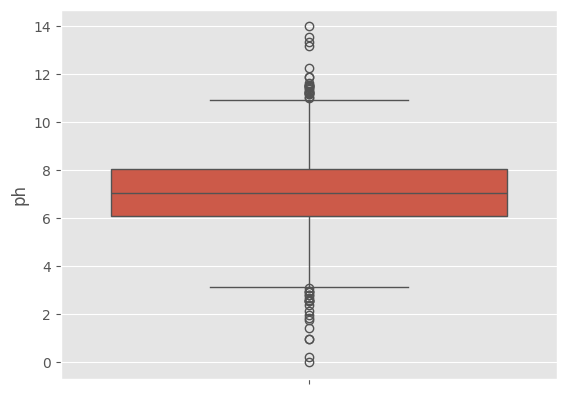

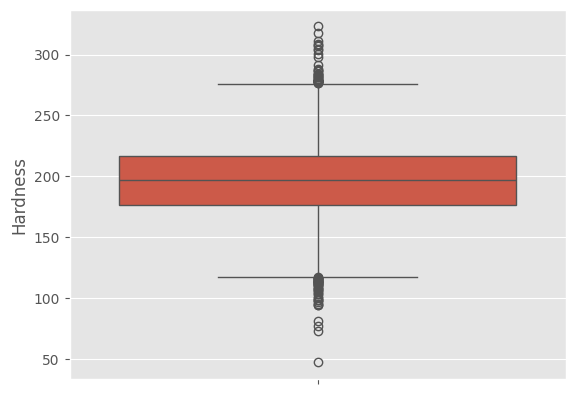

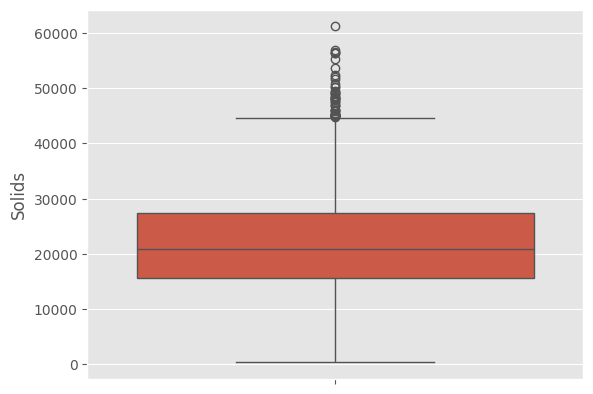

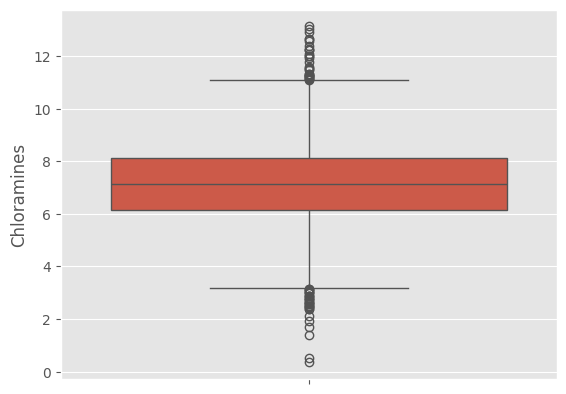

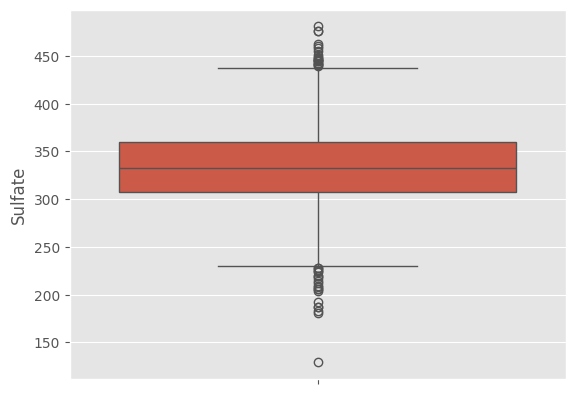

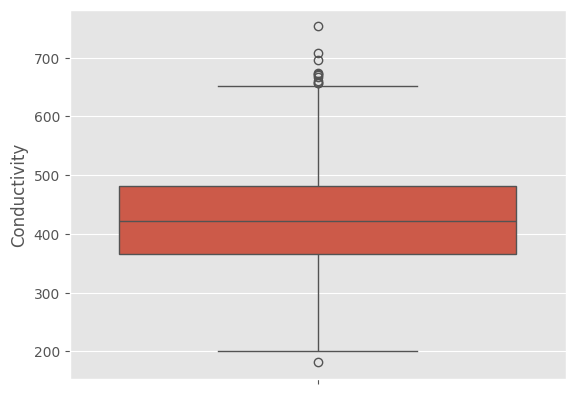

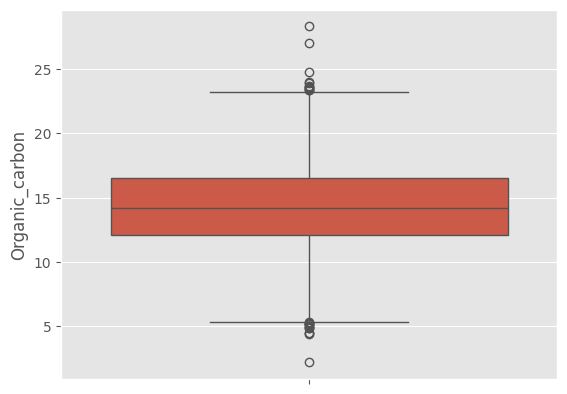

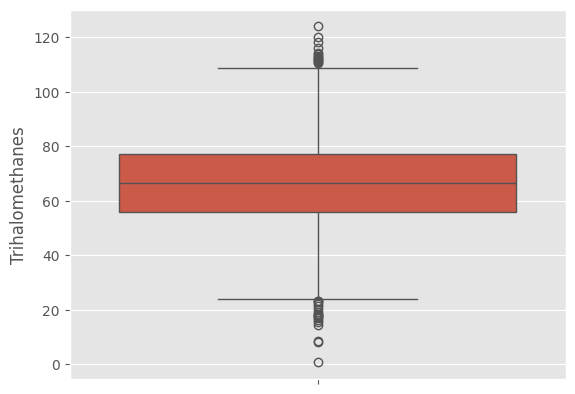

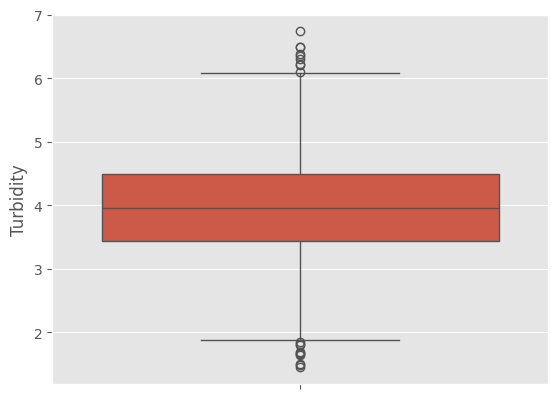

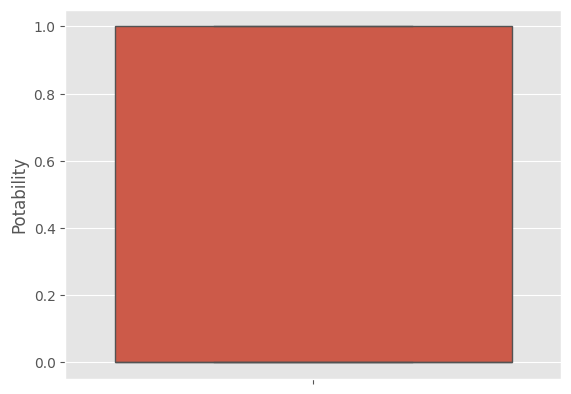

In [16]:
#Observation :
#Alomost All the data points distributed symmetrically ...only 'Solids' feature is little bit positively skewed, so we can..work with it.
#Checking for outliers
for i in df.columns:
    sns.boxplot(df[i])
    plt.show()


In [17]:
#Almost all columns have outliers present. But due to small size of data we decided to not delete the outliers but to impute them with upper and lower boundaries by using IQR
#compute interquantile range to calculate the boundaries
#lower_boundries= [] upper_boundries= [] for i in df.columns: IQR= df[i].quantile(0.75) - df[i].quantile(0.25) lower_bound= df[i].quantile(0.25) - (1.5IQR) upper_bound= df[i].quantile(0.75) + (1.5IQR)
#print(i, ":", lower_bound, ",",  upper_bound)
#lower_boundries.append(lower_bound)
#upper_boundries.append(upper_bound)
#compairing min values and lower boundries
#print(lower_boundries) print("\n") print(df.min())
#replacing the all the outliers which is lower then lower boundary by lower boundary
#k = 0 for i in df.columns: df.loc[df[i] < lower_boundries[k], i] = int(lower_boundries[k]) k = k + 1
#compairing max values and upper boundries
#print(upper_boundries) print("\n") print(df.max())
#replacing the all the outliers which is greater then upper boundary by upper boundary
#j = 0 for i in df.columns: df.loc[df[i] > upper_boundries[j], i] = int(upper_boundries[j]) j = j + 1
#for i in df.columns: sns.boxplot(df[i]) plt.show()
#print(df.min()) print(df.max())
#as we removed the outlier from data and we build the model ..we find that we get a low accurcy So, we are considering our data with the outlier.
df.isna().sum()

ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64

In [18]:
((df.isna().sum())/3276)*100

ph                 14.987790
Hardness            0.000000
Solids              0.000000
Chloramines         0.000000
Sulfate            23.840049
Conductivity        0.000000
Organic_carbon      0.000000
Trihalomethanes     4.945055
Turbidity           0.000000
Potability          0.000000
dtype: float64

In [19]:
#calculating mean values for each field for both categories
#for sulfate
sulfate_0 = df[df['Potability']==0]['Sulfate'].mean(skipna=True)
sulfate_1 = df[df['Potability']==1]['Sulfate'].mean(skipna=True)
#for ph
ph_0 = df[df['Potability']==0]['ph'].mean(skipna=True)
ph_1 = df[df['Potability']==1]['ph'].mean(skipna=True)
#for Trihalomethanes
Trihalo_0 = df[df['Potability']==0]['Trihalomethanes'].mean(skipna=True)
Trihalo_1 = df[df['Potability']==1]['Trihalomethanes'].mean(skipna=True)

In [20]:
d = {'Sulfate':[sulfate_0,sulfate_1,df['Sulfate'].mean()],'ph':[ph_0,ph_1,df['ph'].mean()],
     'Trihalomethanes':[Trihalo_0,Trihalo_1,df['Trihalomethanes'].mean()]}
mean_df = pd.DataFrame(data=d,index=['Potability 0','Potability 1','Population mean'])
mean_df

,Sulfate,ph,Trihalomethanes
Potability 0,334.564290,7.085378,66.303555
Potability 1,332.566990,7.073783,66.539684
Population mean,333.775777,7.080795,66.396293


In [21]:
#sulfate mean imputation
df.loc[(df['Potability'] == 0) & (df['Sulfate'].isna()), 'Sulfate'] = sulfate_0
df.loc[(df['Potability'] == 1) & (df['Sulfate'].isna()), 'Sulfate'] = sulfate_1

In [22]:
#ph mean imputation
df.loc[(df['Potability'] == 0) & (df['ph'].isna()), 'ph'] = ph_0
df.loc[(df['Potability'] == 1) & (df['ph'].isna()), 'ph'] = ph_1

In [23]:
#Trihalomethanes mean imputation
df.loc[(df['Potability'] == 0) & (df['Trihalomethanes'].isna()), 'Trihalomethanes'] = Trihalo_0
df.loc[(df['Potability'] == 1) & (df['Trihalomethanes'].isna()), 'Trihalomethanes'] = Trihalo_1

In [24]:
df.isna().sum()

ph                 0
Hardness           0
Solids             0
Chloramines        0
Sulfate            0
Conductivity       0
Organic_carbon     0
Trihalomethanes    0
Turbidity          0
Potability         0
dtype: int64

In [25]:
df.corr()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
ph,1.000000,0.075878,-0.081887,-0.031827,0.014785,0.017205,0.040092,0.003009,-0.036211,-0.003848
Hardness,0.075878,1.000000,-0.046899,-0.030054,-0.092718,-0.023915,0.003610,-0.012718,-0.014449,-0.013837
Solids,-0.081887,-0.046899,1.000000,-0.070148,-0.149809,0.013831,0.010242,-0.008849,0.019546,0.033743
Chloramines,-0.031827,-0.030054,-0.070148,1.000000,0.023490,-0.020486,-0.012653,0.016615,0.002363,0.023779
Sulfate,0.014785,-0.092718,-0.149809,0.023490,1.000000,-0.014196,0.027403,-0.025797,-0.009523,-0.026957
Conductivity,0.017205,-0.023915,0.013831,-0.020486,-0.014196,1.000000,0.020966,0.001238,0.005798,-0.008128
Organic_carbon,0.040092,0.003610,0.010242,-0.012653,0.027403,0.020966,1.000000,-0.012944,-0.027308,-0.030001
Trihalomethanes,0.003009,-0.012718,-0.008849,0.016615,-0.025797,0.001238,-0.012944,1.000000,-0.021540,0.007305
Turbidity,-0.036211,-0.014449,0.019546,0.002363,-0.009523,0.005798,-0.027308,-0.021540,1.000000,0.001581
Potability,-0.003848,-0.013837,0.033743,0.023779,-0.026957,-0.008128,-0.030001,0.007305,0.001581,1.000000


<function matplotlib.pyplot.show(close=None, block=None)>

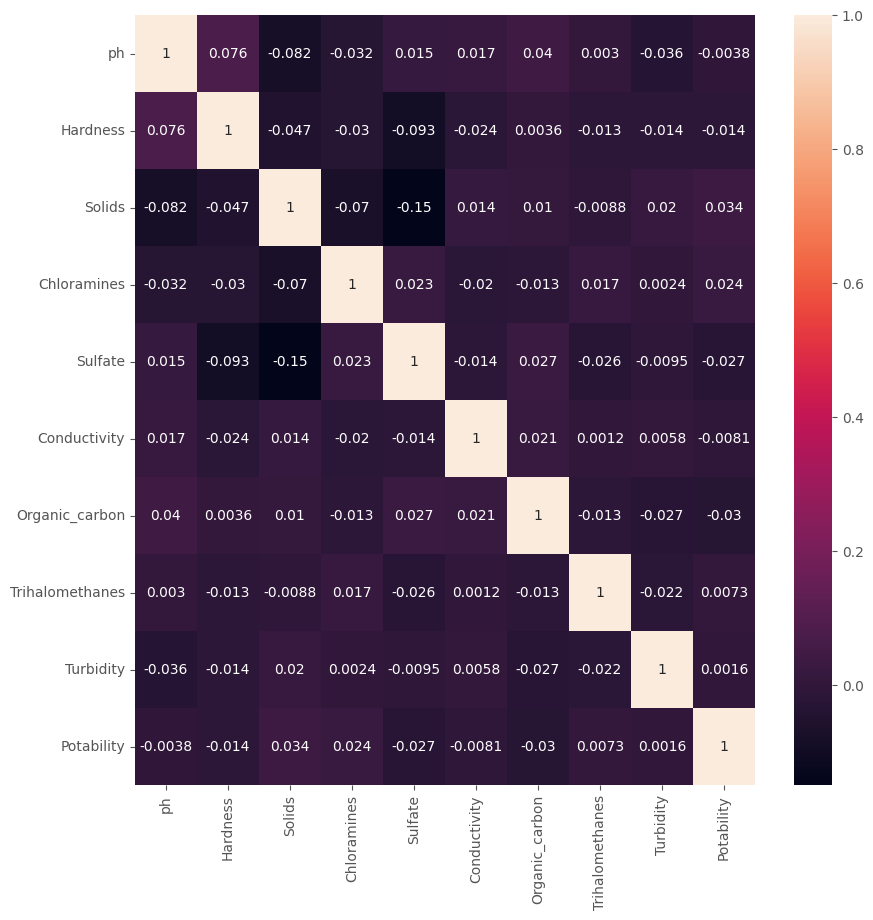

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.subplots(figsize=(10,10))

sns.heatmap(df.corr(),annot=True)
plt.show

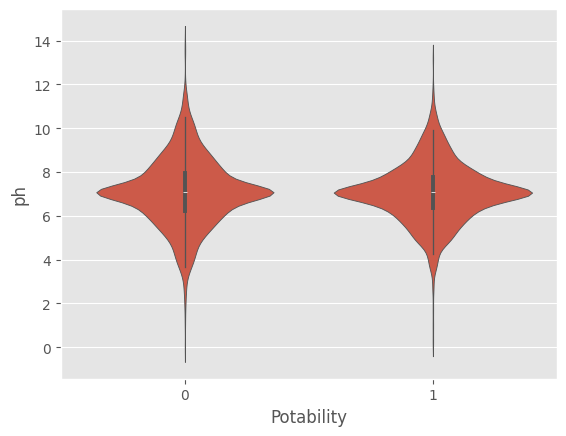

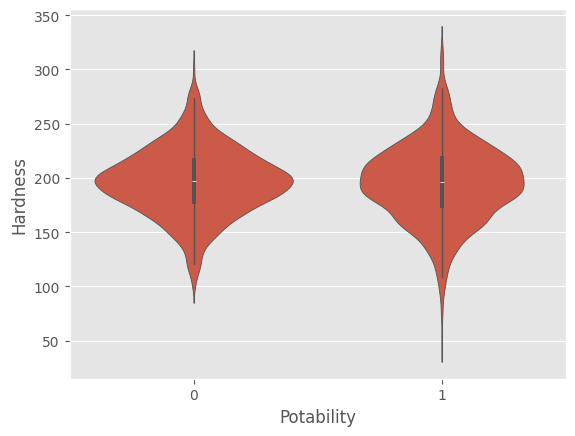

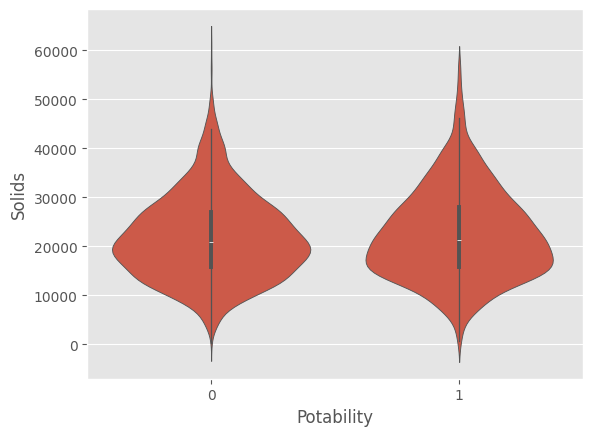

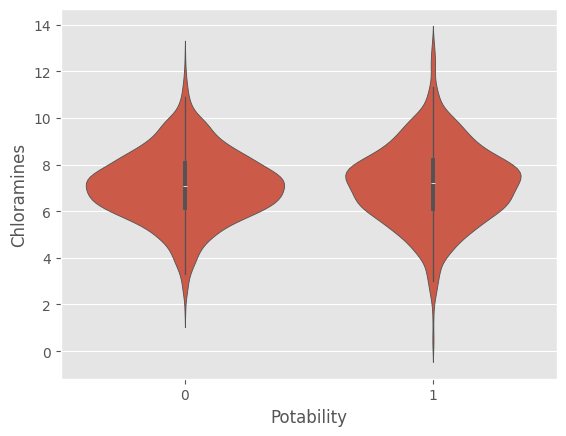

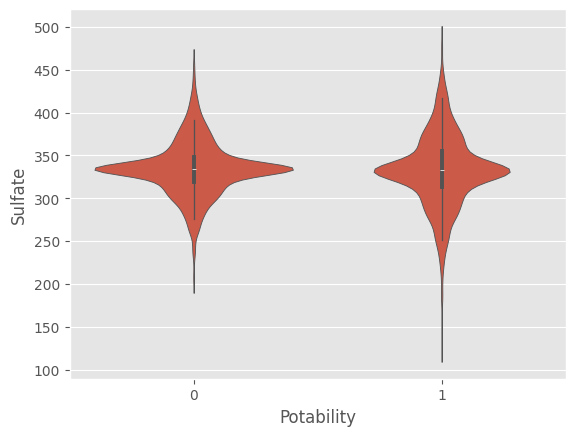

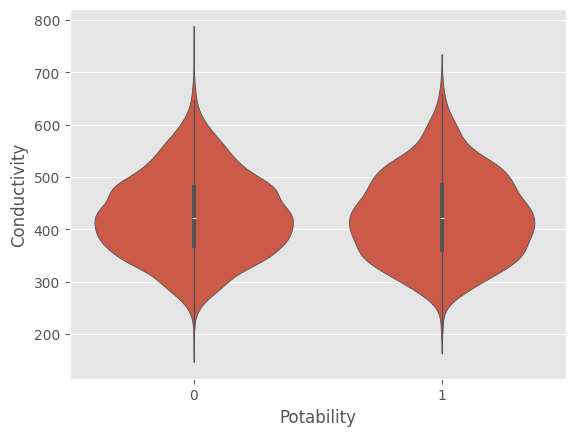

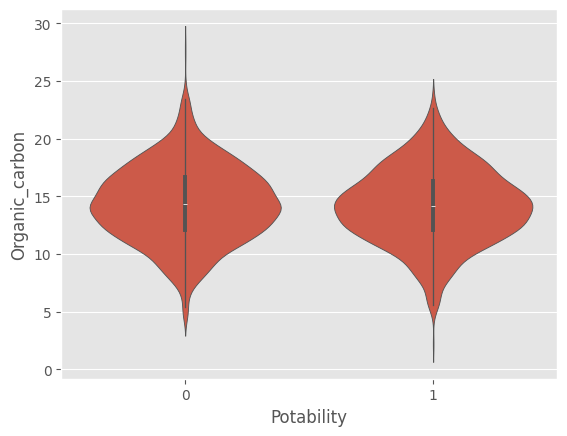

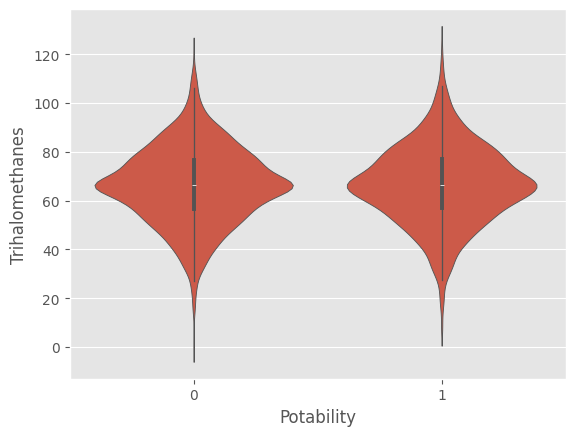

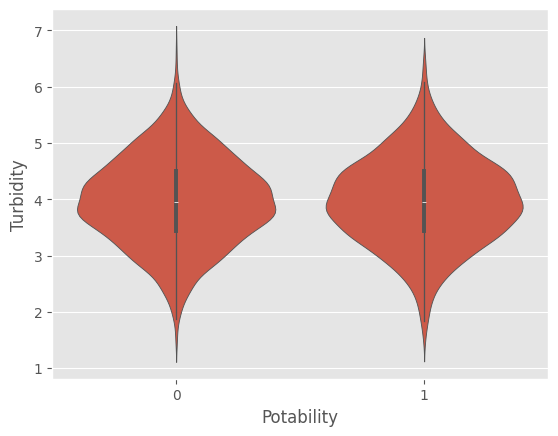

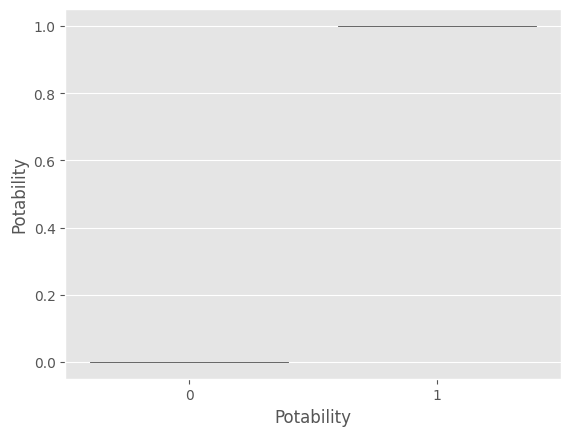

In [27]:
#No highly correlated data was found after imputation. So we will use all the features for model training.
#Multivariate analysis
for i in df.columns:
    sns.violinplot(x='Potability', y=df[i], data=df)
    plt.show()

In [29]:
X=df.drop('Potability',axis=1)


In [31]:
# =========================
# Step 1: Import Libraries
# =========================
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# =========================
# Step 2: Load Dataset
# =========================
df = pd.read_csv(r"C:\Users\KIIT\Downloads\water_potability.csv")

# =========================
# Step 3: Basic Info
# =========================
print("First 5 rows:\n", df.head())
print("\nMissing values:\n", df.isnull().sum())

# =========================
# Step 4: Handle Missing Values
# =========================
# Fill missing values with column mean
df.fillna(df.mean(), inplace=True)

# =========================
# Step 5: Define Features & Target
# =========================
X = df.drop('Potability', axis=1)
y = df['Potability']

# =========================
# Step 6: Train-Test Split
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# =========================
# Step 7: Feature Scaling
# =========================
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# =========================
# Step 8: Model Function
# =========================
def evaluate_model(model):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    print(f"\nModel: {model.__class__.__name__}")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))

# =========================
# Step 9: Train Models
# =========================

# Logistic Regression
evaluate_model(LogisticRegression())

# Random Forest
evaluate_model(RandomForestClassifier(n_estimators=100, random_state=42))

# XGBoost
evaluate_model(XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    use_label_encoder=False,
    eval_metric='logloss'
))

# =========================
# Step 10: Done
# =========================

First 5 rows:
          ph    Hardness        Solids  Chloramines     Sulfate  Conductivity  \
0       NaN  204.890455  20791.318981     7.300212  368.516441    564.308654   
1  3.716080  129.422921  18630.057858     6.635246         NaN    592.885359   
2  8.099124  224.236259  19909.541732     9.275884         NaN    418.606213   
3  8.316766  214.373394  22018.417441     8.059332  356.886136    363.266516   
4  9.092223  181.101509  17978.986339     6.546600  310.135738    398.410813   

   Organic_carbon  Trihalomethanes  Turbidity  Potability  
0       10.379783        86.990970   2.963135           0  
1       15.180013        56.329076   4.500656           0  
2       16.868637        66.420093   3.055934           0  
3       18.436524       100.341674   4.628771           0  
4       11.558279        31.997993   4.075075           0  

Missing values:
 ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivit

In [32]:
X.shape,y.shape

((3276, 9), (3276,))

In [34]:
#import standardscaler to perform scaling
#from sklearn.preprocessing import StandardScaler scaler=StandardScaler()
#X=scaler.fit_transform(X) X
#import train-test split
from sklearn.model_selection import train_test_split

In [35]:
#import train-test split
from sklearn.model_selection import train_test_split

In [36]:
#using logistic regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix,accuracy_score,classification_report

In [38]:
from sklearn.linear_model import LogisticRegression
# create model
model_lr = LogisticRegression()
# train model
model_lr.fit(X_train, y_train)
# prediction
y_pred = model_lr.predict(X_test)

In [39]:
#LogisticRegression(max_iter=120, n_jobs=20, random_state=0)
#In a Jupyter environment, please rerun this cell to show the HTML representation or trust the notebook.
#On GitHub, the HTML representation is unable to render, please try loading this page with nbviewer.org.
#making prediction
pred_lr=model_lr.predict(X_test)

In [40]:
#calculate the accuracy score
lr=accuracy_score(y_test,pred_lr)
print(lr)

0.6097560975609756


In [41]:
print(classification_report(y_test,pred_lr))

              precision    recall  f1-score   support

           0       0.61      1.00      0.76       400
           1       0.00      0.00      0.00       256

    accuracy                           0.61       656
   macro avg       0.30      0.50      0.38       656
weighted avg       0.37      0.61      0.46       656



<Axes: >

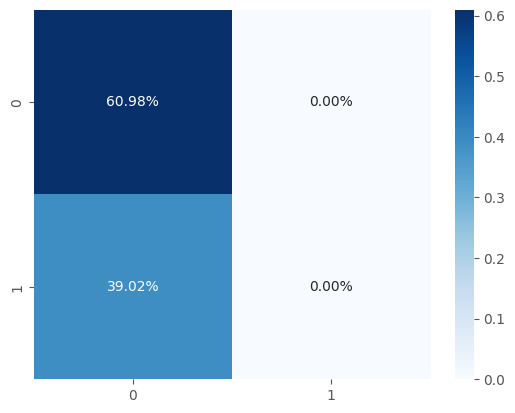

In [42]:
#confusion matrix
cm1=confusion_matrix(y_test,pred_lr)
sns.heatmap(cm1/np.sum(cm1),annot=True,fmt='0.2%',cmap='Blues')

In [43]:
#using decesion tree classifier
from sklearn.tree import DecisionTreeClassifier

In [44]:
#creating the model
model_dt=DecisionTreeClassifier(max_depth=4,random_state=42)

In [45]:
#training the model
model_dt.fit(X_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [46]:
#DecisionTreeClassifier(max_depth=4, random_state=42)
#In a Jupyter environment, please rerun this cell to show the HTML representation or trust the notebook.
#On GitHub, the HTML representation is unable to render, please try loading this page with nbviewer.org.
#making the prediction of model
pred_dt=model_dt.predict(X_test)

In [47]:
#calculate the accuracy score
dt=accuracy_score(y_test,pred_dt)
print(dt)

0.6295731707317073


In [48]:
print(classification_report(y_test,pred_dt))

              precision    recall  f1-score   support

           0       0.63      0.94      0.76       400
           1       0.61      0.14      0.22       256

    accuracy                           0.63       656
   macro avg       0.62      0.54      0.49       656
weighted avg       0.62      0.63      0.55       656



<Axes: >

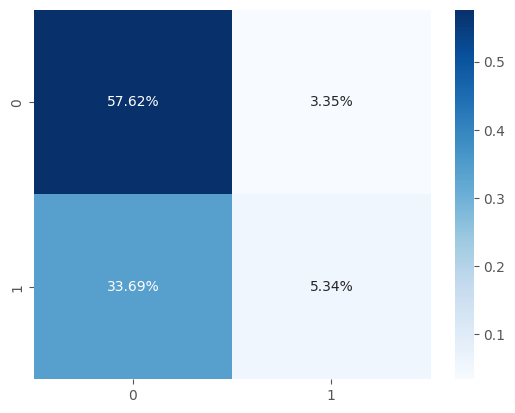

In [49]:
#confusion matrix
cm2=confusion_matrix(y_test,pred_dt)
sns.heatmap(cm2/np.sum(cm2),annot=True,fmt='0.2%',cmap='Blues')

In [50]:
#using random forest classifier.
from sklearn.ensemble import RandomForestClassifier

In [51]:

#creating the model object
model_rf=RandomForestClassifier(n_estimators=300,min_samples_leaf=0.16,random_state=42)

In [52]:
#using XGBoost classifier
from xgboost import XGBClassifier

In [53]:
#creating the model
model_xgb=XGBClassifier(max_depth=8,n_estimators=125,random_state=0,learning_rate=0.03,n_jobs=5)

In [54]:
#training the model
model_xgb.fit(X_train,y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [55]:
#training the model
model_xgb.fit(X_train,y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [56]:
#In a Jupyter environment, please rerun this cell to show the HTML representation or trust the notebook.
#On GitHub, the HTML representation is unable to render, please try loading this page with nbviewer.org.
#making the prediction
pred_xgb=model_xgb.predict(X_test)

In [57]:
#calculating accuracy score of model
xgb=accuracy_score(y_test,pred_xgb)
print(xgb)

0.6737804878048781


In [58]:
print(classification_report(y_test,pred_xgb))

              precision    recall  f1-score   support

           0       0.68      0.90      0.77       400
           1       0.67      0.33      0.44       256

    accuracy                           0.67       656
   macro avg       0.67      0.61      0.60       656
weighted avg       0.67      0.67      0.64       656



<Axes: >

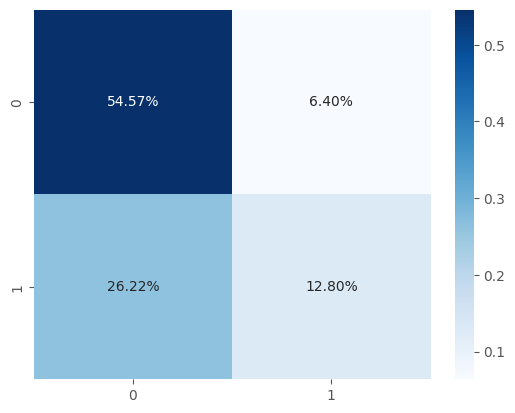

In [59]:
#confusion matrix
cm4=confusion_matrix(y_test,pred_xgb)
sns.heatmap(cm4/np.sum(cm4),annot=True,fmt='0.2%',cmap='Blues')

In [60]:
#using KNeighbours
from sklearn.neighbors import KNeighborsClassifier

In [61]:
#creating the model
model_kn=KNeighborsClassifier(n_neighbors=9,leaf_size=20)

In [62]:
#training the model
model_kn.fit(X_train,y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",9
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",20
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [63]:
#KNeighborsClassifier(leaf_size=20, n_neighbors=9)
#In a Jupyter environment, please rerun this cell to show the HTML representation or trust the notebook.
#On GitHub, the HTML representation is unable to render, please try loading this page with nbviewer.org.
#making the prediction of the model
pred_kn=model_kn.predict(X_test)

In [64]:
#calculating the accuracy score of the model
kn=accuracy_score(y_test,pred_kn)
print(kn)

0.6097560975609756


In [65]:
print(classification_report(y_test,pred_kn))

              precision    recall  f1-score   support

           0       0.64      0.83      0.72       400
           1       0.50      0.27      0.35       256

    accuracy                           0.61       656
   macro avg       0.57      0.55      0.53       656
weighted avg       0.58      0.61      0.58       656



<Axes: >

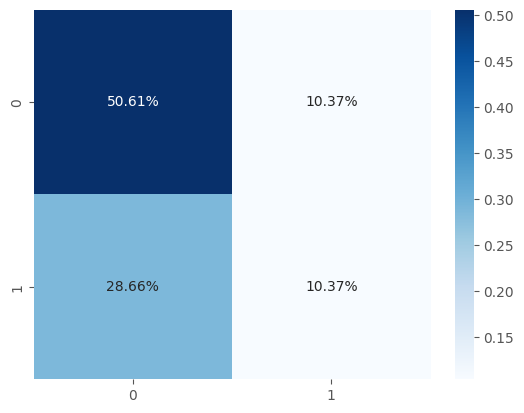

In [66]:
#confusion matrix
cm5=confusion_matrix(y_test,pred_kn)
sns.heatmap(cm5/np.sum(cm5),annot=True,fmt='0.2%',cmap='Blues')

In [67]:
#using support vector machine(svm)
from sklearn.svm import SVC,LinearSVC

In [68]:
#creating the model
model_svm=SVC(kernel='rbf',random_state=42)

In [69]:
#training the model
model_svm.fit(X_train,y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [70]:
#SVC(random_state=42)
#In a Jupyter environment, please rerun this cell to show the HTML representation or trust the notebook.
#On GitHub, the HTML representation is unable to render, please try loading this page with nbviewer.org.
#making the model prediction
pred_svm=model_svm.predict(X_test)

In [71]:
#calculating the accuracy score of the model
asv=accuracy_score(y_test,pred_svm)
print(asv)


0.6692073170731707


In [72]:
print(classification_report(y_test,pred_svm))

              precision    recall  f1-score   support

           0       0.66      0.93      0.77       400
           1       0.70      0.27      0.39       256

    accuracy                           0.67       656
   macro avg       0.68      0.60      0.58       656
weighted avg       0.68      0.67      0.62       656



<Axes: >

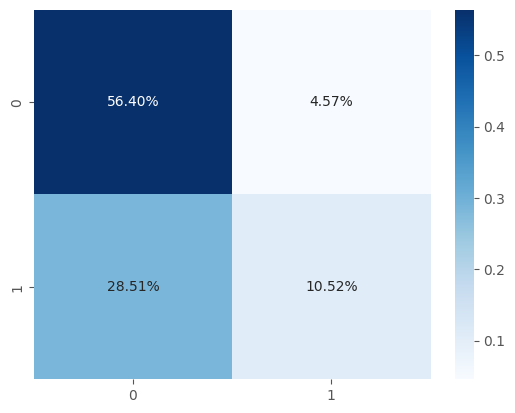

In [73]:
#confusion matrix
cm6=confusion_matrix(y_test,pred_svm)
sns.heatmap(cm6/np.sum(cm6),annot=True,fmt='0.2%',cmap='Blues')


Model Comparison:

                 Model  Accuracy
5                  SVM  0.669207
2        Random Forest  0.652439
3              XGBoost  0.629573
4                  KNN  0.611280
0  Logistic Regression  0.609756
1        Decision Tree  0.589939


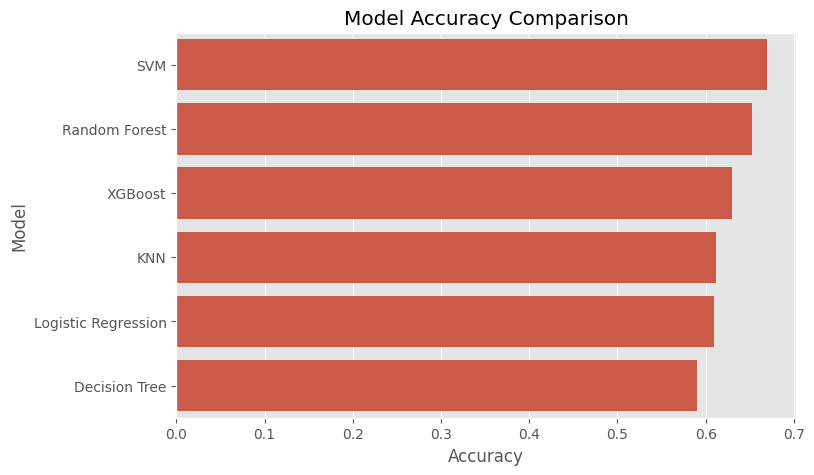


Best Model: SVM


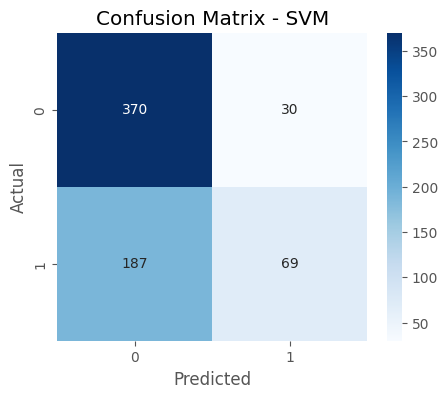


Classification Report:

              precision    recall  f1-score   support

           0       0.66      0.93      0.77       400
           1       0.70      0.27      0.39       256

    accuracy                           0.67       656
   macro avg       0.68      0.60      0.58       656
weighted avg       0.68      0.67      0.62       656



In [75]:
# =========================
# 1. Import Libraries
# =========================
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from xgboost import XGBClassifier

# =========================
# 2. Load Dataset
# =========================
df = pd.read_csv(r"C:\Users\KIIT\Downloads\water_potability.csv")

# =========================
# 3. Preprocessing
# =========================
df.fillna(df.mean(), inplace=True)

X = df.drop('Potability', axis=1)
y = df['Potability']

# =========================
# 4. Train-Test Split
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# =========================
# 5. Scaling
# =========================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# =========================
# 6. Models Dictionary
# =========================
models_dict = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC()
}

# =========================
# 7. Train & Evaluate
# =========================
results = []
trained_models = {}

for name, model in models_dict.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    
    results.append((name, acc))
    trained_models[name] = model

# =========================
# 8. Results DataFrame
# =========================
models_df = pd.DataFrame(results, columns=['Model', 'Accuracy'])
models_df = models_df.sort_values(by='Accuracy', ascending=False)

print("\nModel Comparison:\n")
print(models_df)

# =========================
# 9. Plot Accuracy
# =========================
plt.figure(figsize=(8,5))
sns.barplot(x='Accuracy', y='Model', data=models_df)
plt.title("Model Accuracy Comparison")
plt.show()

# =========================
# 10. Best Model
# =========================
best_model_name = models_df.iloc[0]['Model']
best_model = trained_models[best_model_name]

print(f"\nBest Model: {best_model_name}")

# =========================
# 11. Confusion Matrix
# =========================
y_pred_best = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# =========================
# 12. Classification Report
# =========================
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_best))

In [76]:
import pickle

In [77]:
pickle.dump(model_xgb, open('mymodel.pkl', 'wb'))

In [78]:
pickled_model = pickle.load(open('mymodel.pkl', 'rb'))
xgb_pred = pickled_model.predict(X_test)

In [79]:
acc=accuracy_score(y_test,xgb_pred)
print(acc)

0.6737804878048781


In [80]:
input_data = (8.197353369384867,203.1050914346406,27701.794054691156,6.472914285587643,328.88683761881884,444.612723622325,14.25087508151961,62.90620518305302,3.3618333238544555
)
#changing input data as numpy array
input_as_np = np.array(input_data,dtype=np.float64)
#reshaping the data
input_reshaped = input_as_np.reshape(1,-1)
prediction_xgb = pickled_model.predict(input_reshaped)
print(prediction_xgb)
if(prediction_xgb[0] == 0):
    print('The water is not potable')
else:
    print('The water is potable')

[1]
The water is potable


In [81]:
print(input_data)

(8.197353369384867, 203.1050914346406, 27701.794054691156, 6.472914285587643, 328.88683761881884, 444.612723622325, 14.25087508151961, 62.90620518305302, 3.3618333238544555)


In [82]:
!pip install xgboost

In [84]:
!pip install missingno

In [85]:
#Der Datensatz der für diese Auswertung verwendet wurde ist hier zu finden: https://www.kaggle.com/datasets/adityakadiwal/water-potability
#Bibiliotheken importieren
# Basic Libraries
import numpy as np
import pandas as pd
import missingno as msno

# Visualizations Libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Data Pre-processing Libraries
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.utils import resample

# Modelling Libraries
from sklearn.linear_model import LogisticRegression,RidgeClassifier,SGDClassifier,PassiveAggressiveClassifier
from sklearn.linear_model import Perceptron
from sklearn.svm import SVC,NuSVC
from sklearn.neighbors import KNeighborsClassifier,NearestCentroid
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,AdaBoostClassifier,GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB,BernoulliNB

# Evaluation & CV Libraries
from sklearn.metrics import precision_score,accuracy_score,f1_score
from sklearn.model_selection import RandomizedSearchCV,RepeatedStratifiedKFold

In [86]:
#Datensatz laden und Deskriptive Statistik
csv_file_path = r"C:\Users\KIIT\Downloads\water_potability (1).csv"
water_data = pd.read_csv(csv_file_path)

#display the data
water_data.describe().style.background_gradient(cmap="Blues")

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
count,2785.000000,3276.000000,3276.000000,3276.000000,2495.000000,3276.000000,3276.000000,3114.000000,3276.000000,3276.000000
mean,7.080795,196.369496,22014.092526,7.122277,333.775777,426.205111,14.284970,66.396293,3.966786,0.390110
std,1.594320,32.879761,8768.570828,1.583085,41.416840,80.824064,3.308162,16.175008,0.780382,0.487849
min,0.000000,47.432000,320.942611,0.352000,129.000000,181.483754,2.200000,0.738000,1.450000,0.000000
25%,6.093092,176.850538,15666.690297,6.127421,307.699498,365.734414,12.065801,55.844536,3.439711,0.000000
50%,7.036752,196.967627,20927.833607,7.130299,333.073546,421.884968,14.218338,66.622485,3.955028,0.000000
75%,8.062066,216.667456,27332.762127,8.114887,359.950170,481.792304,16.557652,77.337473,4.500320,1.000000
max,14.000000,323.124000,61227.196008,13.127000,481.030642,753.342620,28.300000,124.000000,6.739000,1.000000


In [87]:
##Insgesamt gibt es 3276 Dateneinträge
#ph:
#Der durchschnittliche pH-Wert liegt bei 7,08 was leicht saures bis neutrales Wasser anzeigt.
#Die Standardabweichung von 1,59 deutet auf einen relativ großen Bereich von pH-Werten hin.
#Der minimale pH-Wert liegt bei 0,0, was extrem niedrig ist und wahrscheinlich ein Ausreißer oder ein Messfehler ist.
#Der maximale pH-Wert liegt bei 14,0 was extrem hoch ist und ebenfalls wahrscheinlich ein Ausreißer oder ein Messfehler ist.
#Hardness:
#Die durchschnittliche Härte beträgt 196,37 mg/L, was auf mäßig hartes Wasser hinweist.
#Die Standardabweichung von 32,88 mg/L deutet auf einen relativ engen Bereich von Härtewerten hin.
#Die minimale Härte beträgt 47,43 mg/L und die maximale 323,12 mg/L, was auf einen weiten Bereich von Härtegraden hinweist.
#Solids (TDS):
#Der durchschnittliche TDS-Wert liegt bei 22.014,09 mg/L, was sehr hoch ist und auf eine erhebliche Menge an gelösten Feststoffen im Wasser hinweist.
#Die Standardabweichung von 8.768,57 mg/L deutet auf einen breiten Bereich von TDS-Werten hin.
#Der minimale TDS-Wert liegt bei 320,94 mg/L und der maximale Wert bei 61.227,20 mg/L, was auf einen sehr breiten Bereich von TDS-Werten hinweist.
#Chloramines:
#Der durchschnittliche Chloraminwert liegt bei 7,12 mg/L, was sehr hoch ist.
#Die Standardabweichung von 1,58 mg/L deutet auf einen relativ engen Bereich von Chloraminwerten hin.
#Der minimale Chloraminwert beträgt 0,35 mg/L und der maximale Wert liegt bei 13,13 mg/L, was auf einen weiten Bereich von Chloraminkonzentrationen hinweist.
#Sulfate:
#Der durchschnittliche Sulfatwert liegt bei 333,78 mg/L, was sehr hoch ist.
#Die Standardabweichung von 41,42 mg/L deutet auf einen relativ engen Bereich von Sulfatwerten hin.
#Der minimale Sulfatwert beträgt 129,0 mg/L und der maximale Wert 481,03 mg/L, was auf einen moderaten Bereich von Sulfatkonzentrationen hinweist.
#Conductivity:
#Die durchschnittliche Leitfähigkeit beträgt 426,21 μS/cm, was relativ hoch ist und auf eine erhebliche Menge an gelösten Ionen im Wasser hinweist.
#Die Standardabweichung von 80,82 μS/cm deutet auf einen mäßig breiten Bereich von Leitfähigkeitswerten hin.
#Die minimale Leitfähigkeit beträgt 181,48 μS/cm und die maximale Leitfähigkeit 753,34 μS/cm, was auf einen breiten Bereich von Leitfähigkeitswerten hinweist.
#Organic Carbon:
#Der durchschnittliche Gehalt an organischem Kohlenstoff beträgt 14,28 mg/L, was sehr hoch ist.
#Die Standardabweichung von 3,31 mg/L deutet auf einen relativ engen Bereich der organischen Kohlenstoffwerte hin.
#Der minimale Gehalt an organischem Kohlenstoff beträgt 2,2 mg/L und der maximale Wert 28,3 mg/L, was auf einen moderaten Bereich der organischen Kohlenstoffkonzentration hinweist.
#Trihalomethanes:
#Der durchschnittliche Trihalomethangehalt beträgt 66,40 μg/L, was im üblichen Bereich für Trinkwasser liegt.
#Die Standardabweichung von 16,18 μg/L deutet auf einen relativ engen Bereich von Trihalomethanwerten hin.
#Der minimale Trihalomethangehalt beträgt 0,74 μg/L und der maximale Wert liegt bei 124,0 μg/L, was auf einen breiten Bereich von Trihalomethankonzentration hinweist.
#Turbidity:
#Die durchschnittliche Trübung beträgt 3,97 NTU, was im typischen Bereich für Trinkwasser liegt.
#Die Standardabweichung von 0,78 NTU deutet auf einen relativ engen Bereich von Trübungswerten hin.
#Die minimale Trübung beträgt 1,45 NTU und die maximale Trübung 6,74 NTU, was auf einen moderaten Bereich von Trübungswerten hinweist.

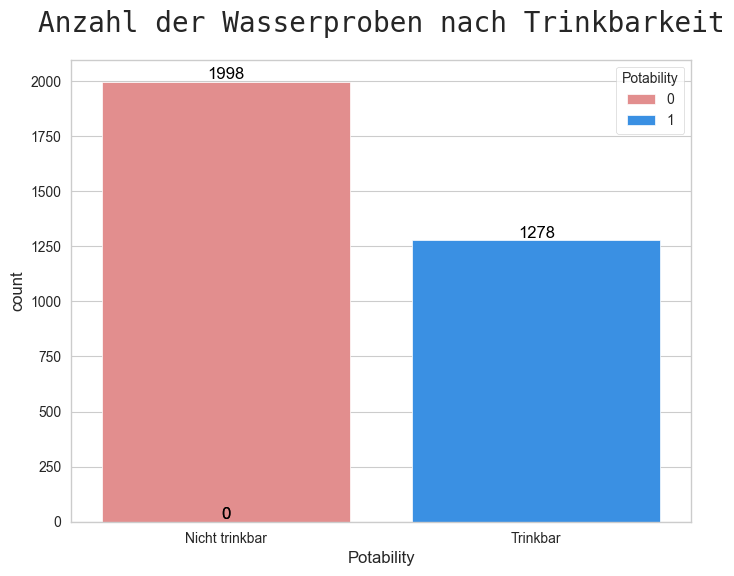

In [88]:
# Set the aesthetic style of the plots
sns.set_style("whitegrid")

# Create a count plot
plt.figure(figsize=(8, 6))
ax = sns.countplot(x='Potability', data=water_data, hue='Potability', palette=['lightcoral', 'dodgerblue'])

# Rename the x-axis labels
ax.set_xticklabels(['Nicht trinkbar', 'Trinkbar'])

# Set the title of the plot
plt.title('Anzahl der Wasserproben nach Trinkbarkeit', font='monospace', fontsize=20, pad=20)

# Label the axes
#plt.xlabel('Trinkbarkeit', font='monospace', fontsize=14, labelpad=20)
#plt.ylabel('Anzahl der Proben', font='monospace', fontsize=14, labelpad=20)

# Annotate the count above the bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=12, color='black', xytext=(0, 5),
                textcoords='offset points')

# Show the plot
plt.show()

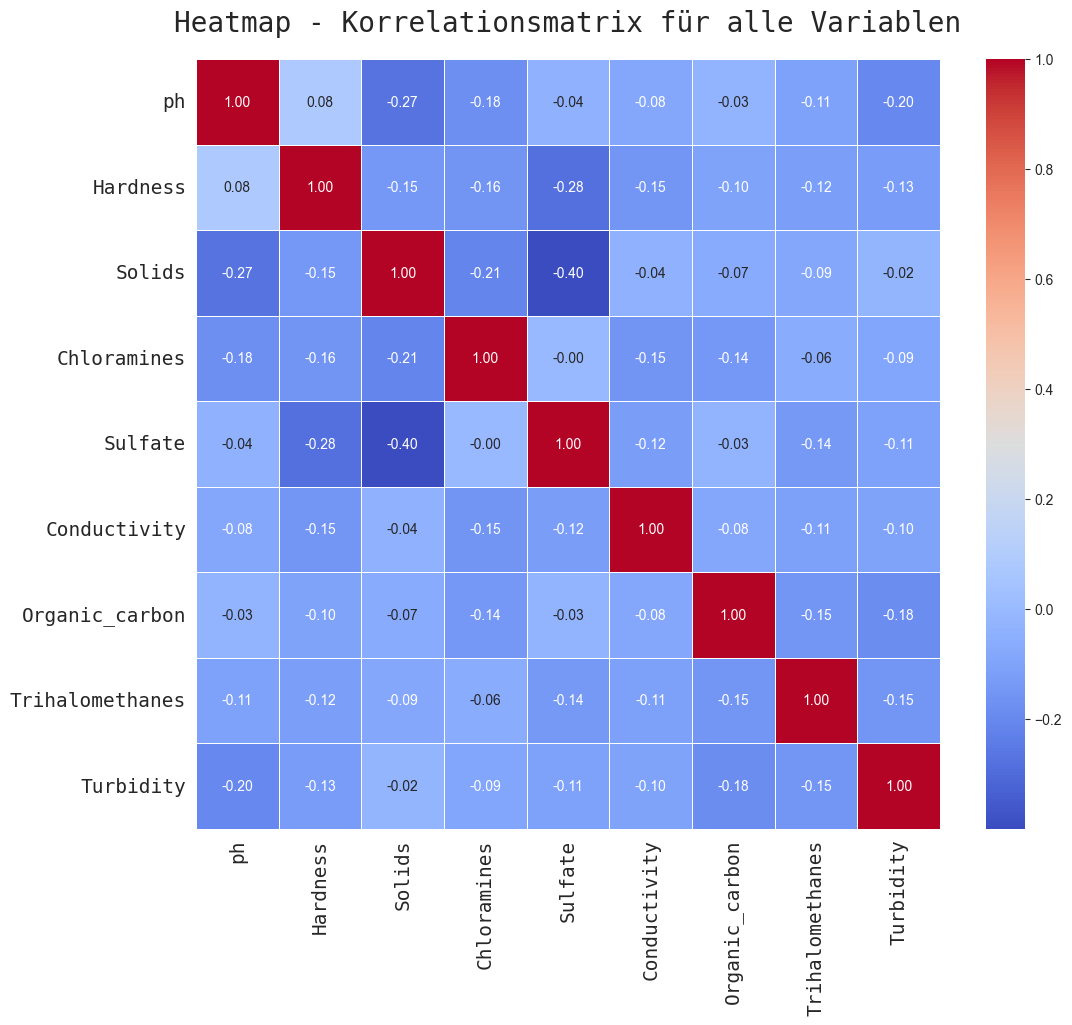

In [89]:
#Korrelationskoeffizienten Analyse:
#Ziel: Das Hauptziel der Analyse von Korrelationskoeffizienten ist es, den Zusammenhang bzw. die Stärke und Richtung der Beziehung zwischen zwei Variablen in einem Datensatz zu untersuchen.
#Durch die Berechnung von Korrelationskoeffizienten wie Pearson, Spearman oder anderen Maßen können folgende Punkte analysiert werden:
#Stärke der Beziehung erkennen: Wie stark korrelieren zwei Variablen miteinander? Je näher der Korrelationskoeffizient an +1 oder -1 liegt, desto stärker ist die Beziehung.
#Richtung der Beziehung bestimmen: Ist die Beziehung positiv (beide Variablen bewegen sich in die gleiche Richtung) oder negativ (Variablen bewegen sich gegenläufig)?
#Lineare Zusammenhänge identifizieren: Korrelationen zeigen an ob zwischen den Variablen ein linearer Zusammenhang besteht.
#Redundante Variablen erkennen: Sehr hoch korrelierende Variablen können redundant sein, was bei Modellen zu Problemen führen kann.
#Datenexploration und Generierung von Hypothesen: Hohe oder niedrige Korrelationen können Ausgangspunkt für weitere Analysen und Untersuchungen potenzieller Kausalzusammenhänge sein (datatab, 2024)
cor=water_data.drop('Potability',axis=1).corr()
corr_matrix = cor.corr(numeric_only=True)
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Heatmap - Korrelationsmatrix für alle Variablen",font="monospace",fontsize=20, pad=20)
plt.xticks(font="monospace", fontsize=14)
plt.yticks(font="monospace", fontsize=14)
plt.show()

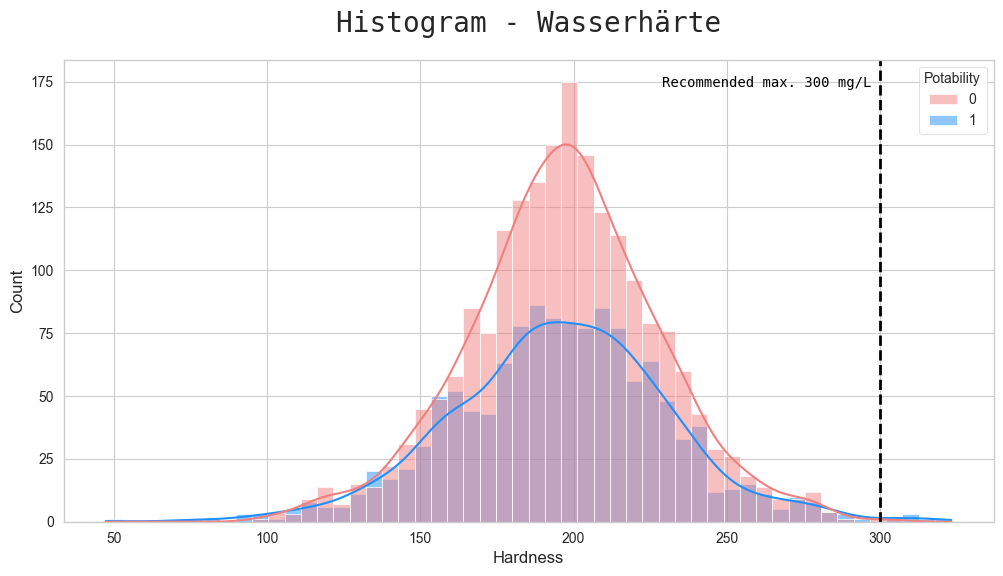

In [90]:
#Ergebnis:
#Wie man sieht ist die Heatmap ziemlich kalt (blau), es gibt also keinen Hinweis auf eine positive Korrelation zwischen den Variablen.
#Allgemein in einer Korrelationsmatrix als Heatmap: Zeilen = y-Achse Spalten = x-Achse
#Es besteht eine mittlere negative Korrelation von -0.40 zwischen der Variable "Solids" und der Variable "Sulfate".
#Mit anderen Worten, höhere Werte von "Solids" gehen tendenziell mit niedrigeren Werten von "Sulfate" einher und umgekehrt.
#Scatter Plots:
#Wir erstellen Scatter Plots (Streudiagramme) um die Beziehung zwischen der Trinkbarkeit und anderen Variablen wie pH-Wert, Härte, gelösten Feststoffen, Chloraminen usw. zu visualisieren.
#Dies kann dabei helfen potenzielle lineare oder nicht-lineare Zusammenhänge zu identifizieren.
palette = {0: "lightcoral", 1: "dodgerblue"}

# Create a histogram for hardness vs. water quality
plt.figure(figsize=(12, 6))
plt.title("Histogram - Wasserhärte",font="monospace",fontsize=20, pad=20)
sns.histplot(data=water_data, x='Hardness', hue='Potability', kde=True, palette=palette)
plt.axvline(x=300, color='black', linestyle='--', linewidth=2)
plt.text(297, plt.gca().get_ylim()[1]*0.95, 'Recommended max. 300 mg/L', color = 'black', ha='right', va='center', fontsize=10, fontname='monospace')
plt.show()

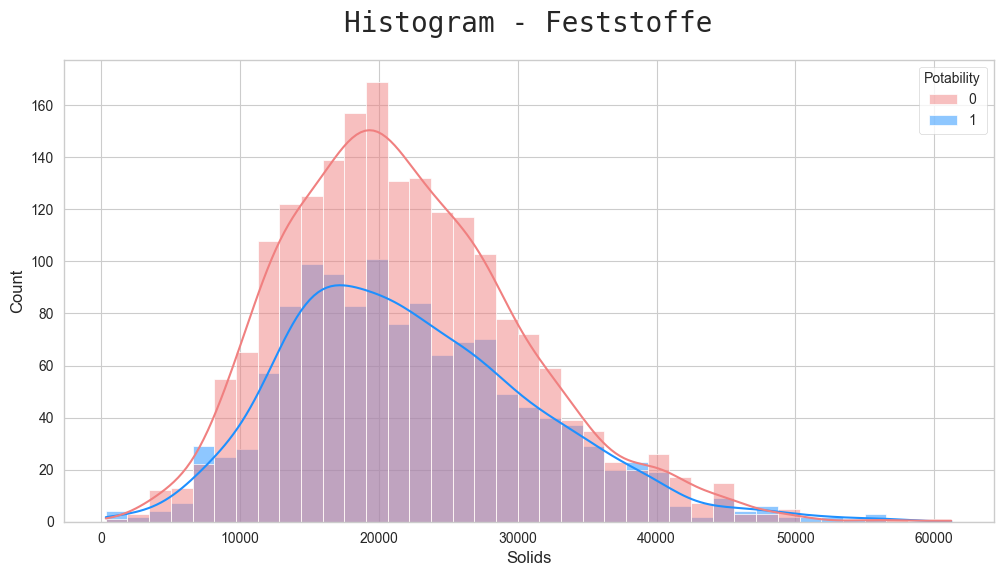

In [91]:
#Die Wasserhärte wird hauptsächlich durch Calcium- und Magnesiumsalze verursacht. Diese Salze werden aus geologischen Ablagerungen gelöst durch die das Wasser fließt. Die Dauer in der das Wasser mit dem härteverursachenden Material in Kontakt ist bestimmt den Härtegrad des Rohwassers (Ansel, 2005).
#Der pH-Wert der meisten Trinkwasserproben liegt im Bereich von 6,5 bis 8,5. Natürliche Gewässer können einen niedrigeren pH-Wert aufweisen, beispielsweise aufgrund von saurem Regen oder einen höheren pH-Wert in Kalksteingebieten (WHO, 2017).
# Histogramm of solids
plt.figure(figsize=(12, 6))
plt.title("Histogram - Feststoffe",font="monospace",fontsize=20, pad=20)
sns.histplot(data=water_data, x='Solids', hue='Potability', kde=True, palette=palette)
plt.show()


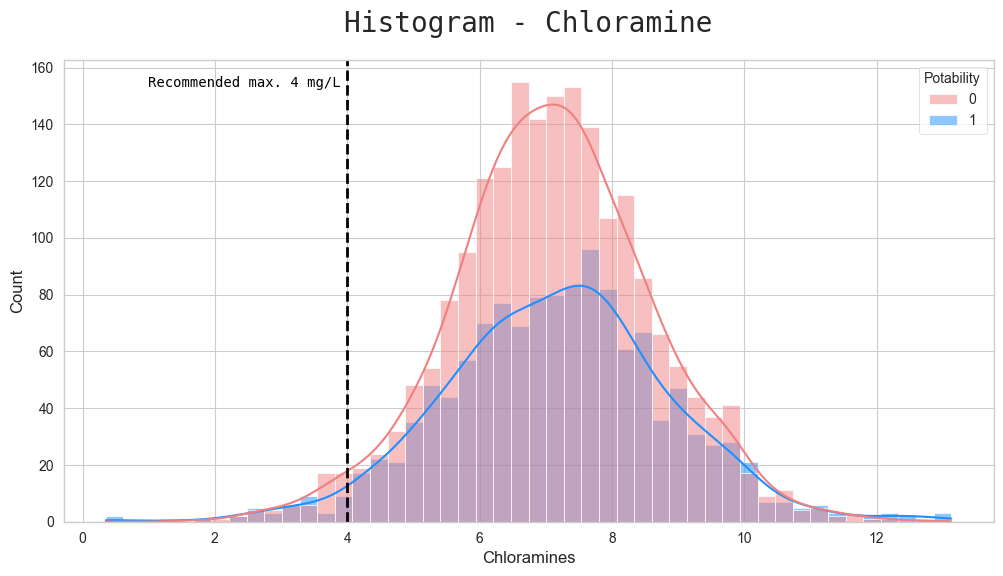

In [92]:
# Histogram of chloramines
plt.figure(figsize=(12, 6))
plt.title("Histogram - Chloramine",font="monospace",fontsize=20, pad=20)
sns.histplot(data=water_data, x='Chloramines', hue='Potability', kde=True, palette=palette)
plt.axvline(x=4, color='black', linestyle='--', linewidth=2)
plt.text(3.90, plt.gca().get_ylim()[1]*0.95, 'Recommended max. 4 mg/L', color = 'black', ha='right', va='center', fontsize=10, fontname='monospace')
plt.show()

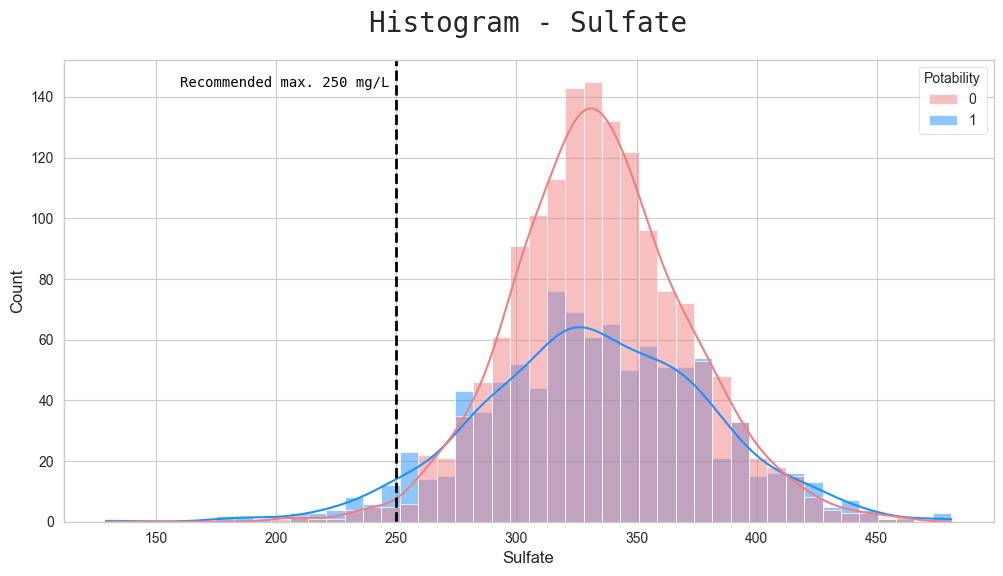

In [93]:
#Chloramine werden gebildet wenn Chlor zur Behandlung von Trinkwasser mit Ammoniak versetzt wird. Sie können zu Augen- und Nasenreizung, Magenbeschwerden (Sodbrennen, Übelkeit, Erbrechen, Magenschmerzen) und Anämie führen (EPA, 2023).
# Histogram of sulfate
plt.figure(figsize=(12, 6))
plt.title("Histogram - Sulfate",font="monospace",fontsize=20, pad=20)
sns.histplot(data=water_data, x='Sulfate', hue='Potability', kde=True, palette=palette)
plt.axvline(x=250, color='black', linestyle='--', linewidth=2)
plt.text(247, plt.gca().get_ylim()[1]*0.95, 'Recommended max. 250 mg/L', color = 'black', ha='right', va='center', fontsize=10, fontname='monospace')
plt.show()

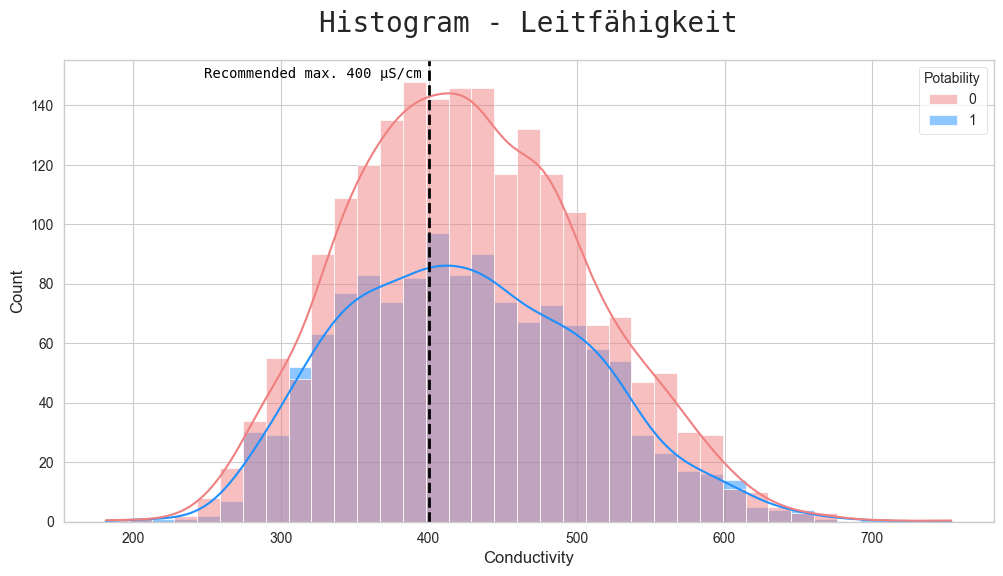

In [94]:
#Sulfate kommen häufig in natürlichen Wasserquellen vor und sind natürlicherweise in Mineralien, Böden und Gesteinen enthalten. Sie können auch über industrielle Abwässer in die Wasserversorgung gelangen. Sulfate gelten in normalen Konzentrationen nicht als giftig für den Menschen. Die Aufnahme von Wasser mit einem hohen Sulfatgehalt kann zu Durchfall und Dehydrierung führen, insbesondere bei Säuglingen (EPA, 2023).
# Histogram of conductivity
plt.figure(figsize=(12, 6))
plt.title("Histogram - Leitfähigkeit",font="monospace",fontsize=20, pad=20)
sns.histplot(data=water_data, x='Conductivity', hue='Potability', kde=True, palette=palette)
plt.axvline(x=400, color='black', linestyle='--', linewidth=2)
plt.text(395, plt.gca().get_ylim()[1]*0.97, 'Recommended max. 400 μS/cm', color = 'black', ha='right', va='center', fontsize=10, fontname='monospace')
plt.show()

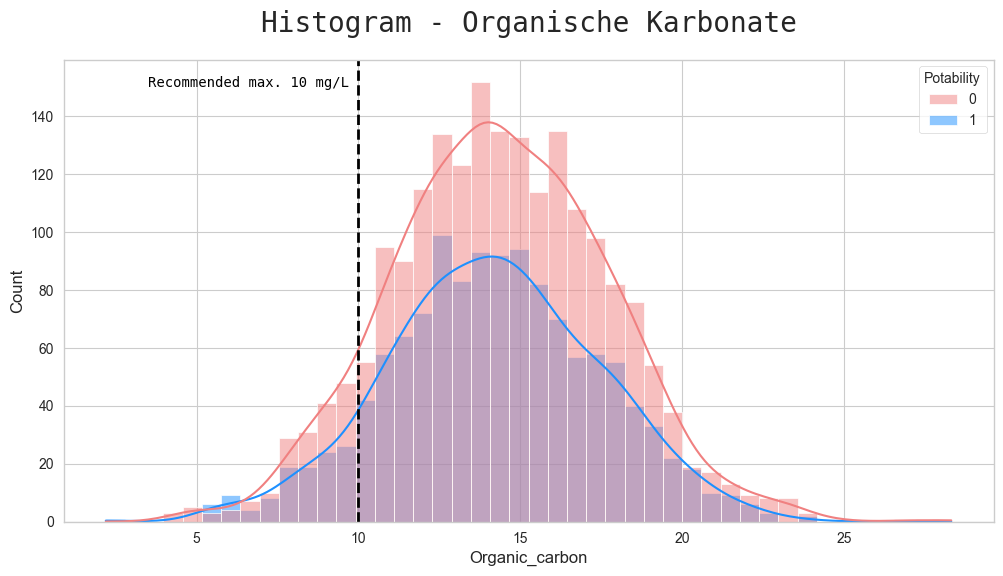

In [95]:
#Histogram of Organic Carbon
plt.figure(figsize=(12, 6))
plt.title("Histogram - Organische Karbonate",font="monospace",fontsize=20, pad=20)
sns.histplot(data=water_data, x='Organic_carbon', hue='Potability', kde=True, palette=palette)
plt.axvline(x=10, color='black', linestyle='--', linewidth=2)
plt.text(9.7, plt.gca().get_ylim()[1]*0.95, 'Recommended max. 10 mg/L', color = 'black', ha='right', va='center', fontsize=10, fontname='monospace')
plt.show()

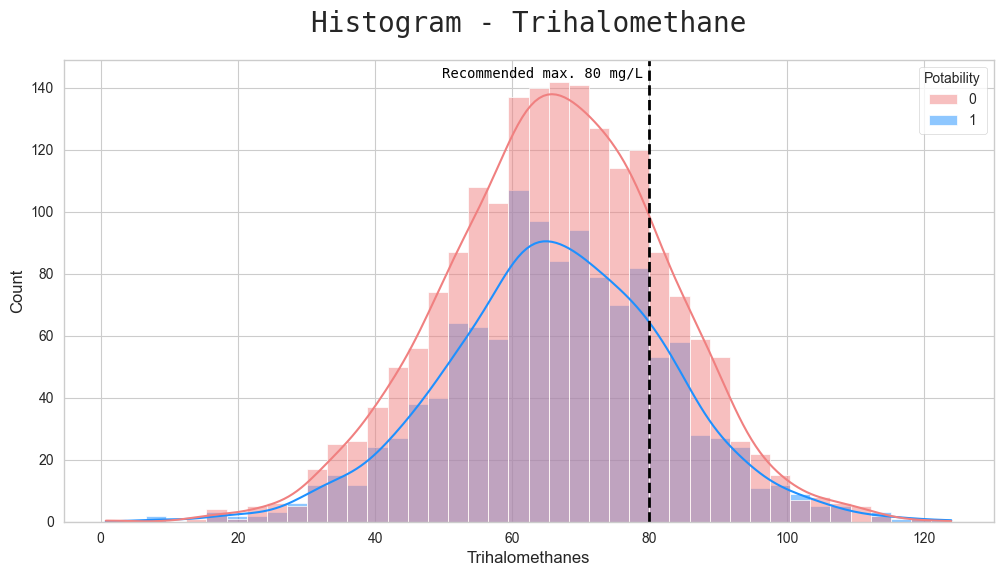

In [96]:
# Histogram of Trihalomethanes
plt.figure(figsize=(12, 6))
plt.title("Histogram - Trihalomethane",font="monospace",fontsize=20, pad=20)
sns.histplot(data=water_data, x='Trihalomethanes', hue='Potability', kde=True, palette=palette)
plt.axvline(x=80, color='black', linestyle='--', linewidth=2)
plt.text(79, plt.gca().get_ylim()[1]*0.97, 'Recommended max. 80 mg/L', color = 'black', ha='right', va='center', fontsize=10, fontname='monospace')
plt.show()

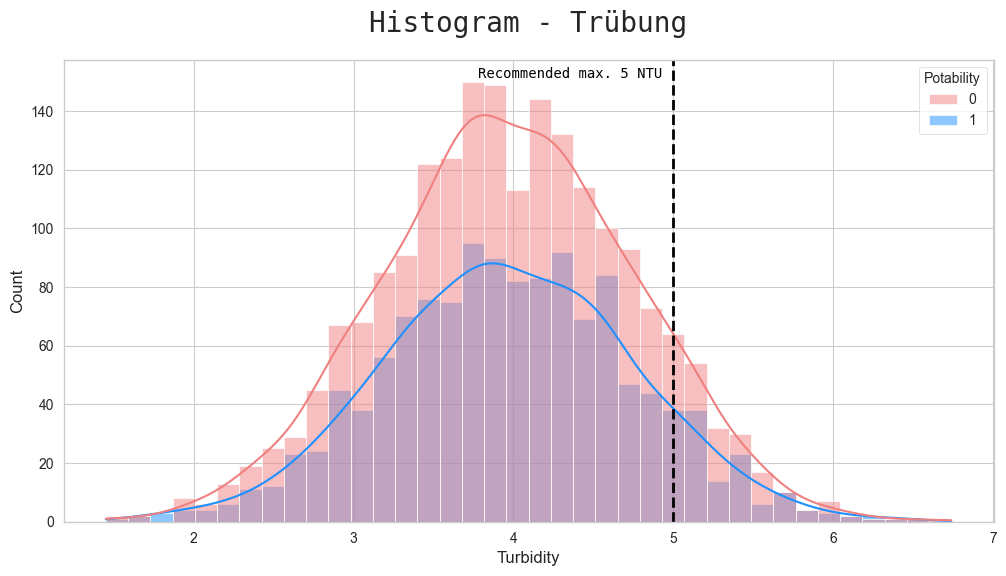

In [97]:
#Trihalomethane sind Chemikalien die in chlorbehandeltem Wasser vorkommen können. Erhöhte Trihalomethanwerte werden mit Leber-, Nieren- oder Probleme mit dem zentralen Nervensystem und erhöhtem Krebsrisiko in Verbindung gebracht (EPA, 2023).
# Histogram of Turbidity
plt.figure(figsize=(12, 6))
plt.title("Histogram - Trübung",font="monospace",fontsize=20, pad=20)
sns.histplot(data=water_data, x='Turbidity', hue='Potability', kde=True, palette=palette)
plt.axvline(x=5, color='black', linestyle='--', linewidth=2)
plt.text(4.93, plt.gca().get_ylim()[1]*0.97, 'Recommended max. 5 NTU', color = 'black', ha='right', va='center', fontsize=10, fontname='monospace')
plt.show()

In [98]:
#Data Preprocessing:
#Das Data Preprocessing umfasst nicht nur die Bereinigung und Transformation von Daten, sondern auch die Organisation von Rohdaten um sie für das ML geeignet zu machen. Zu den Tasks gehören der Umgang mit fehlenden Werten, die Skalierung von Merkmalen, die Kodierung kategorischer Variablen sowie die Aufteilung der Daten in Trainings- und Testdatensätze.
water_data.isnull().sum()

ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64

In [99]:
water_data.isnull().sum() / len(water_data) * 100

ph                 14.987790
Hardness            0.000000
Solids              0.000000
Chloramines         0.000000
Sulfate            23.840049
Conductivity        0.000000
Organic_carbon      0.000000
Trihalomethanes     4.945055
Turbidity           0.000000
Potability          0.000000
dtype: float64

<Axes: >

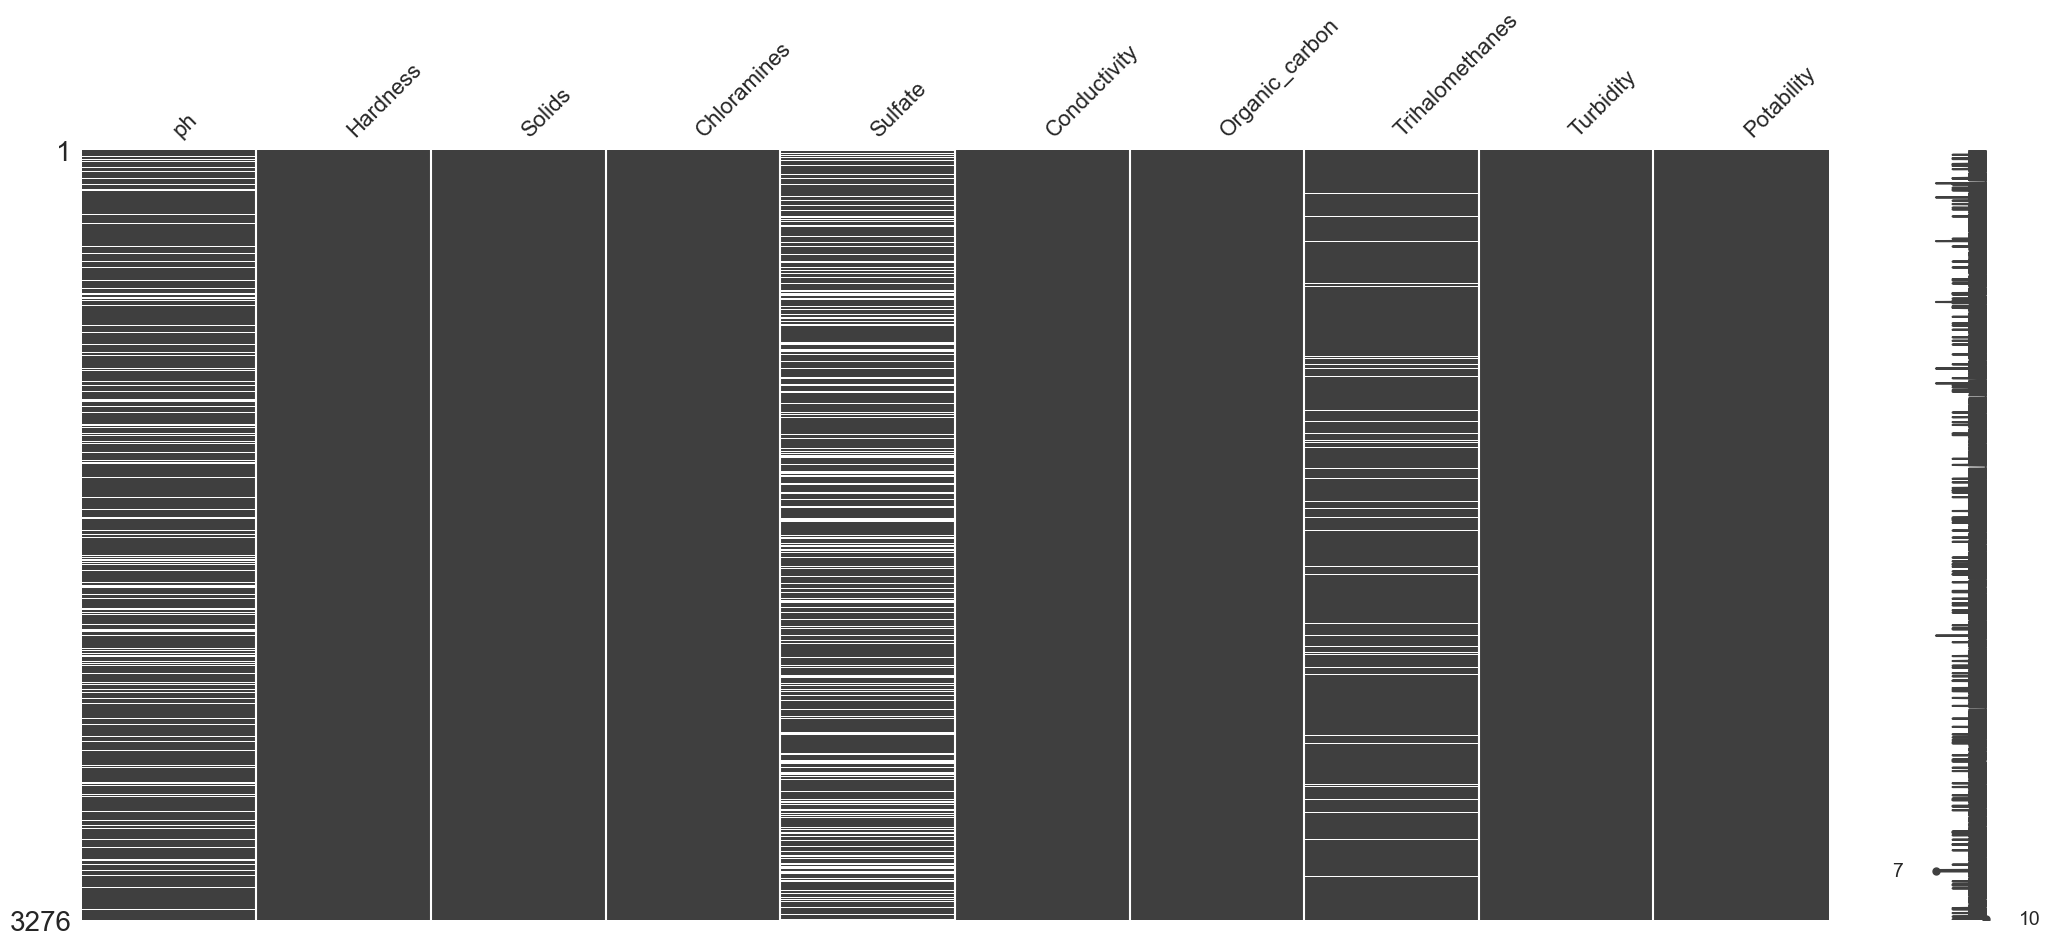

In [100]:
#Es fehlen folgende Werte im Datensatz:
#pH: 491
#Sulfate: 781
#Trihalomethanes: 162
#In Prozent:
#ph: 14.98%
#Sulfate: 23.84%
#Trihalometahnes: 4.94%
#Man könnte die fehlenden Werte auch entfernen, jedoch macht man das in Regel nur bei bis zu 3% an fehlenden Daten - 
#ansonten haben wir größere einbußen beim Modeltraining.
msno.matrix(water_data)

In [101]:
# Compare the difference between the means of Potability == 0 and Potability == 1
water_data[water_data['Potability'] == 0].describe().style.background_gradient(cmap="Blues")

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
count,1684.000000,1998.000000,1998.000000,1998.000000,1510.000000,1998.000000,1998.000000,1891.000000,1998.000000,1998.000000
mean,7.085378,196.733292,21777.490788,7.092175,334.564290,426.730454,14.364335,66.303555,3.965800,0.000000
std,1.683499,31.057540,8543.068788,1.501045,36.745549,80.047317,3.334554,16.079320,0.780282,0.000000
min,0.000000,98.452931,320.942611,1.683993,203.444521,181.483754,4.371899,0.738000,1.450000,0.000000
25%,6.037723,177.823265,15663.057382,6.155640,311.264006,368.498530,12.101057,55.706530,3.444062,0.000000
50%,7.035456,197.123423,20809.618280,7.090334,333.389426,422.229331,14.293508,66.542198,3.948076,0.000000
75%,8.155510,216.120687,27006.249009,8.066462,356.853897,480.677198,16.649485,77.277704,4.496106,0.000000
max,14.000000,304.235912,61227.196008,12.653362,460.107069,753.342620,28.300000,120.030077,6.739000,0.000000


In [102]:
# Compare the difference between the means of Potability == 0 and Potability == 1
water_data[water_data['Potability'] == 1].describe().style.background_gradient(cmap="Blues")

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
count,1101.000000,1278.000000,1278.000000,1278.000000,985.000000,1278.000000,1278.000000,1223.000000,1278.000000,1278.000000
mean,7.073783,195.800744,22383.991018,7.169338,332.566990,425.383800,14.160893,66.539684,3.968328,1.000000
std,1.448048,35.547041,9101.010208,1.702988,47.692818,82.048446,3.263907,16.327419,0.780842,0.000000
min,0.227499,47.432000,728.750830,0.352000,129.000000,201.619737,2.200000,8.175876,1.492207,1.000000
25%,6.179312,174.330531,15668.985035,6.094134,300.763772,360.939023,12.033897,56.014249,3.430909,1.000000
50%,7.036752,196.632907,21199.386614,7.215163,331.838167,420.712729,14.162809,66.678214,3.958576,1.000000
75%,7.933068,218.003420,27973.236446,8.199261,365.941346,484.155911,16.356245,77.380975,4.509569,1.000000
max,13.175402,323.124000,56488.672413,13.127000,481.030642,695.369528,23.604298,124.000000,6.494249,1.000000


In [103]:
#Ersetzen NaN durch Median
water_data[water_data['Potability'] == 0][['ph', 'Sulfate', 'Trihalomethanes']].median()

ph                   7.035456
Sulfate            333.389426
Trihalomethanes     66.542198
dtype: float64

In [104]:
water_data[water_data['Potability'] == 1][['ph', 'Sulfate', 'Trihalomethanes']].median()

ph                   7.036752
Sulfate            331.838167
Trihalomethanes     66.678214
dtype: float64

In [105]:
#Wir können sehen dass der Unterschied zwischen den Median-Werten von trinkbarem und nicht trinkbarem Wasser minimal ist. Daher verwenden wir den Median um die fehlenden Werte zu ersetzen.
water_data['ph'] = water_data['ph'].fillna(water_data['ph'].median())
water_data['Sulfate'] = water_data['Sulfate'].fillna(water_data['Sulfate'].median())
water_data['Trihalomethanes'] = water_data['Trihalomethanes'].fillna(water_data['Trihalomethanes'].median())

water_data.isnull().sum()

ph                 0
Hardness           0
Solids             0
Chloramines        0
Sulfate            0
Conductivity       0
Organic_carbon     0
Trihalomethanes    0
Turbidity          0
Potability         0
dtype: int64

In [106]:
#Standardisieren
#Da wir nun die fehlenden Werte ersetzt haben ist es an der Zeit alle numerischen Merkmale zu standardisieren.
#Warum Standardisierung: Standardisierung stellt sicher dass alle Merkmale gleich stark zum learning beitragen. 
#Außerdem konvergieren viele Algorithmen schneller wenn die Merkmale standardisiert sind.
water_new = water_data.copy()
numeric_columns = water_new.select_dtypes(include=[np.number])
# Initialize the MinMaxScaler --> values between 0 and 1, since we have only positive values
scaler = MinMaxScaler()
numeric_columns_standardized = scaler.fit_transform(numeric_columns)
water_new[numeric_columns.columns] = numeric_columns_standardized
water_new

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,0.502625,0.571139,0.336096,0.543891,0.680385,0.669439,0.313402,0.699753,0.286091,0.0
1,0.265434,0.297400,0.300611,0.491839,0.579704,0.719411,0.497319,0.450999,0.576793,0.0
2,0.578509,0.641311,0.321619,0.698543,0.579704,0.414652,0.562017,0.532866,0.303637,0.0
3,0.594055,0.605536,0.356244,0.603314,0.647347,0.317880,0.622089,0.808065,0.601015,0.0
4,0.649445,0.484851,0.289922,0.484900,0.514545,0.379337,0.358555,0.253606,0.496327,0.0
...,...,...,...,...,...,...,...,...,...,...
3271,0.333436,0.530482,0.775947,0.533436,0.656047,0.603192,0.448062,0.535037,0.564534,1.0
3272,0.557775,0.530016,0.279263,0.603473,0.579704,0.368912,0.678284,0.534508,0.254915,1.0
3273,0.672822,0.465486,0.539101,0.547807,0.579704,0.438152,0.338662,0.560655,0.349570,1.0
3274,0.366197,0.664407,0.191490,0.465860,0.579704,0.387157,0.343638,0.622659,0.616120,1.0


In [107]:
#Test Daten für später ausschneiden:
# Zufällige 5% der Daten auswählen
sample_rows = resample(water_new, replace=False, n_samples=int(0.02 * len(water_new)), random_state=42)

# Ausgewählte Daten als CSV-Datei speichern
sample_rows.to_csv('removed_data.csv', index=False)

# Verbleibende Daten in neuem DataFrame speichern
remaining_data = water_new.drop(sample_rows.index)

In [108]:
#Modelling
#Zuerst den Datensatz in 70% Trainingsset, 30% Validierungs- und Testset aufteilen.
# Ziel-Variable 'Potability' aus dem Datenrahmen entfernen
X = water_new.drop('Potability', axis=1)
y = water_new['Potability']

# Aufteilen in Trainings-(70%),(30%) Validierungs- und Test-Datensatz
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Überprüfung der Größen der Datensätze
print(f"Trainingsset: {len(X_train)} Beispiele")
print(f"Testset: {len(X_test)} Beispiele")

Trainingsset: 2293 Beispiele
Testset: 983 Beispiele


In [109]:
#filterwarnings('ignore')
models =[("LR", LogisticRegression(max_iter=1000)),("SVC", SVC()),('KNN',KNeighborsClassifier(n_neighbors=10)),
         ("DTC", DecisionTreeClassifier()),("GNB", GaussianNB()),
        ("SGDC", SGDClassifier()),("Perc", Perceptron()),("NC",NearestCentroid()),
        ("Ridge", RidgeClassifier()),("NuSVC", NuSVC()),("BNB", BernoulliNB()),
         ('RF',RandomForestClassifier()),('ADA',AdaBoostClassifier()),
        ('XGB',GradientBoostingClassifier()),('PAC',PassiveAggressiveClassifier())]

results = []
names = []
finalResults = []

for name,model in models:
    model.fit(X_train, y_train)
    model_results = model.predict(X_test)
    score = precision_score(y_test, model_results,average='macro')
    results.append(score)
    names.append(name)
    finalResults.append((name,score))
    
finalResults.sort(key=lambda k:k[1],reverse=True)

finalResults

[('SVC', 0.7073723914960321),
 ('RF', 0.6653313237082871),
 ('XGB', 0.6389745987221442),
 ('NuSVC', 0.6330215000820614),
 ('ADA', 0.6186638388123011),
 ('GNB', 0.5890578719526087),
 ('KNN', 0.586237779205024),
 ('Perc', 0.5642272262026612),
 ('DTC', 0.5444702242846094),
 ('NC', 0.5115112502899559),
 ('LR', 0.3138351983723296),
 ('SGDC', 0.3138351983723296),
 ('Ridge', 0.3138351983723296),
 ('BNB', 0.3138351983723296),
 ('PAC', 0.1861648016276704)]

In [ ]:
#Die Ergebnisse zeigen, dass SVC, RF (Random Forest) und XGB (Gradient Boost) die besten Leistungen erzielt haben. 
#Der nächste Schritt wäre, die Hyperparameter dieser Modelle randomisiert zu optimieren um diese zu evaluieren und "fertig zu trainieren".
model_params = {
    'XGB': {
        'model': GradientBoostingClassifier(),
        'params': {
            'learning_rate': [0.0001, 0.001, 0.01, 0.1],
            'n_estimators': [100, 200, 500, 1000],
            'max_features': ['sqrt', 'log2'],
            'max_depth': list(range(11))
        }
    },
    'Random Forest': {
        'model': RandomForestClassifier(),
        'params': {
            'n_estimators': [10, 50, 100, 200],
            'max_features': ['auto', 'sqrt', 'log2'],
            'max_depth': list(range(1, 11))
        }
    },
    'SVC': {
        'model': SVC(),
        'params': {
            'C': [0.1, 1, 10, 100],
            'kernel': ['rbf', 'poly', 'sigmoid'],
            'gamma': ['scale', 'auto']
        }
    }
}

cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=2, random_state=42)
scores = []
for model_name, params in model_params.items():
    rs = RandomizedSearchCV(params['model'], params['params'], cv=cv, n_iter=20, n_jobs=-1)
    rs.fit(X_train, y_train)
    scores.append([model_name, dict(rs.best_params_), rs.best_score_])
data = pd.DataFrame(scores, columns=['Model', 'Parameters', 'Score'])
data


In [ ]:
# Beste Hyperparameter für XGBoost aus der Randomized Search
best_xgb_params = {'n_estimators': 500, 'max_features': 'sqrt', 'max_depth': 7, 'learning_rate': 0.01}

# XGBoost-Modell mit besten Hyperparametern initialisieren
xgb_model = GradientBoostingClassifier(**best_xgb_params)

# Kreuzvalidierung für Modellbewertung
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=2, random_state=42)

# Listen zum Speichern der Metriken
f1_scores = []
precision_scores = []
accuracy_scores = []

# Kreuzvalidierung durchführen
for train_idx, test_idx in cv.split(X, y):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
    # Modell trainieren
    xgb_model.fit(X_train, y_train)
    
    # Vorhersagen machen
    y_pred = xgb_model.predict(X_test)
    
    # Metriken berechnen und speichern
    f1_scores.append(f1_score(y_test, y_pred))
    precision_scores.append(precision_score(y_test, y_pred))
    accuracy_scores.append(accuracy_score(y_test, y_pred))

# Durchschnittliche Metriken berechnen
avg_f1_score = sum(f1_scores) / len(f1_scores)
avg_precision_score = sum(precision_scores) / len(precision_scores)
avg_accuracy_score = sum(accuracy_scores) / len(accuracy_scores)

print(f"Durchschnittlicher F1-Score: {avg_f1_score:.4f}")
print(f"Durchschnittliche Precision: {avg_precision_score:.4f}")
print(f"Durchschnittliche Accuracy: {avg_accuracy_score:.4f}")

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(xgb_model.predict(X_test),y_test)
disp = ConfusionMatrixDisplay(cm, display_labels=["0","1"])
disp.plot()
plt.title("Confusion Matrix")
plt.show()

In [ ]:
feature_importances=xgb_model.feature_importances_
feature_importances_df=pd.DataFrame({'features':list(X_train), 'feature_importances':feature_importances})
feature_importances_df.sort_values('feature_importances',ascending=False)

In [ ]:
# Calculate ROC curve and AUC
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_curve, roc_auc_score

y_prob = xgb_model.predict_proba(X_test)[:, 1]  # Probability of positive class
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(8, 6))
plt.fill_between(fpr, tpr, color='blue', alpha=0.2, label= f"AUC = {roc_auc:.4f}")
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")

plt.show()

In [ ]:
#Source:
#Ansell, R.O. (2005). ION-SELECTIVE ELECTRODES | Water Applications. Encyclopedia of Analytical Science (Second Edition), 7, 540-545
#datatab. (2024). Korrelationsanalyse. https://datatab.de/tutorial/korrelation
#Environmental Protection Agency (EPA). (2023). National Primary Drinking Water Regulations. https://www.epa.gov/ground-water-and-drinking-water/national-primary-drinking-water-regulations
#Environmental Protection Agency (EPA). (2024). Indicators: Conductivity. https://www.epa.gov/national-aquatic-resource-surveys/indicators-conductivity
#Weltgesundheitsorganisation (WHO). (2017). Guidelines for drinking-water quality - 4th edition. https://cdn.who.int/media/docs/default-source/wash-documents/wash-chemicals/tds.pdf?sfvrsn=3e6d651e_4